# MILPÍN AgTech — Predicción XGBoost v3.0
## Consumo de Agua y Rendimiento Agrícola · Valle del Yaqui, Sonora

| Modelo | Target | Unidad |
|--------|--------|--------|
| M1 — Consumo de agua | `volumen_agua_total_m3_ha` | m³/ha por ciclo |
| M2 — Rendimiento | `rendimiento_real_ton_ha` | ton/ha por ciclo |

**Stack:** `XGBoost 2.x/3.x · scikit-learn · numpy · pandas · matplotlib · seaborn`

**Mejoras v3.0 sobre v2.1:**
- **Generador v3** con alta diversidad estadística (evita convergencia prematura)
- 5 micro-regiones del Valle del Yaqui con heterogeneidad climática y edáfica
- Kc variable por etapa de crecimiento (FAO-56 4-etapas, vectorizado)
- Variabilidad inter-anual: ENSO, drift climático, mejora varietales
- Eventos extremos: ola de calor, helada, inundación, plaga/enfermedad
- Arquetipos de agricultor (conservador, eficiente, negligente, tecnificado)
- Estrés por salinidad independiente del hídrico (FAO-33 extensión)
- Ascenso capilar + percolación profunda (balance hídrico físico)
- Ruido IoT: drift de sensores ET0, humedad de suelo, pluviómetro
- No-estacionariedad temporal: +ET0 año a año, mejora varietales
- **FIX SHAP**: `iteration_range` corregido — valores coherentes con `predict()`

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# MILPÍN — Auto-guardado en ML/images/
# Generado por ML/patch_notebooks.py — NO editar manualmente.
# ═══════════════════════════════════════════════════════════════════
from pathlib import Path
import sys as _sys
import re  as _re
import atexit as _atexit

# ── Directorio de salida ─────────────────────────────────────────────────────
_here = Path().resolve()
IMAGES_DIR = (
    _here.parent / "images"
    if _here.name == "experiments"
    else _here / "ML" / "images"
)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# ── Parche matplotlib: auto-save en plt.show() + redirigir plt.savefig ───────
import matplotlib.pyplot   as _plt
import matplotlib.figure   as _mpl_fig

_saved_fig_ids  = set()
_auto_fig_count = [0]
_orig_plt_show    = _plt.show
_orig_plt_savefig = _plt.savefig
_orig_fig_savefig = _mpl_fig.Figure.savefig

def _auto_fname(fig, n):
    title = (fig._suptitle.get_text() if fig._suptitle else "") or next(
        (ax.get_title() for ax in fig.get_axes() if ax.get_title()), "")
    stem = _re.sub(r"[^\w\-]", "_", title)[:50].strip("_").lower() if title else f"figura_{n:03d}"
    return f"{stem}.png"

def _patched_plt_savefig(fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    fig  = _plt.gcf()
    _orig_fig_savefig(fig, dest, *a, **kw)  # llama directo para evitar doble-parche
    _saved_fig_ids.add(id(fig))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_fig_savefig(self, fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    _orig_fig_savefig(self, dest, *a, **kw)
    _saved_fig_ids.add(id(self))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_plt_show(*a, **kw):
    fig = _plt.gcf()
    if fig.get_axes() and id(fig) not in _saved_fig_ids:
        _auto_fig_count[0] += 1
        fname = _auto_fname(fig, _auto_fig_count[0])
        _orig_fig_savefig(fig, IMAGES_DIR / fname, dpi=150, bbox_inches="tight")
        print(f"  ✓ [auto-imagen] {fname}")
    _saved_fig_ids.discard(id(fig))
    _orig_plt_show(*a, **kw)

_plt.show               = _patched_plt_show
_plt.savefig            = _patched_plt_savefig
_mpl_fig.Figure.savefig = _patched_fig_savefig

# ── Parche pandas: auto-save DataFrames al mostrarse en Jupyter ─────────────
_df_count = [0]
try:
    import pandas as _pd
    _orig_df_repr_html = _pd.DataFrame._repr_html_

    def _patched_df_repr_html(self):
        _df_count[0] += 1
        stem = f"tabla_{_df_count[0]:03d}"
        self.to_csv(IMAGES_DIR / f"{stem}.csv", index=True, encoding="utf-8-sig")
        self.to_html(IMAGES_DIR / f"{stem}.html")
        print(f"  ✓ [tabla] {stem}.csv  ({len(self)} filas × {len(self.columns)} cols)")
        return _orig_df_repr_html(self)

    _pd.DataFrame._repr_html_ = _patched_df_repr_html
except Exception as _pd_err:
    print(f"  ! pandas hook: {_pd_err}")

# ── Capturar stdout → IMAGES_DIR/output_log.txt ──────────────────────────────
_log_path = IMAGES_DIR / "output_log.txt"
_log_file = open(_log_path, "w", encoding="utf-8")

class _Tee:
    def __init__(self, real, log):
        self._real = real
        self._log  = log
    def write(self, s):
        self._real.write(s)
        self._log.write(s)
    def flush(self):
        self._real.flush()
        self._log.flush()
    def __getattr__(self, attr):
        return getattr(self._real, attr)

_sys.stdout = _Tee(_sys.__stdout__, _log_file)
_atexit.register(lambda: (_log_file.flush(), _log_file.close()))

print(f"✓ IMAGES_DIR  → {IMAGES_DIR}")
print(f"✓ matplotlib  → auto-save en show() + redirigir savefig()")
print(f"✓ pandas      → auto-save DataFrames (CSV + HTML)")
print(f"✓ stdout      → {_log_path.name}")


## 0. Configuración e imports

In [29]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (11, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("Set2")
SEED = 42
np.random.seed(SEED)

print(f"numpy    {np.__version__}")
print(f"XGBoost  {xgb.__version__}")

numpy    2.4.4
XGBoost  3.2.0


In [30]:
# ══════════════════════════════════════════════════════════════════
#  AJUSTA N_SAMPLES SEGÚN TU OBJETIVO
#  ────────────────────────────────────────────────────────────────
#   10_000  → benchmark rápido (<30s entrenamiento)
#   50_000  → RECOMENDADO: balance óptimo señal/tiempo
#  300_000  → prueba de escala (~3-5 min)
# 1_000_000 → stress test (~20-30 min, requiere >=8 GB RAM)
#
#  Con el generador v3 (alta diversidad), la convergencia ocurre más
#  tarde (~80k-150k muestras) gracias a:
#  - Heterogeneidad regional y de arquetipos de agricultor
#  - Variabilidad inter-anual (ENSO, drift climático)
#  - Eventos extremos y estrés por salinidad
#  - Ruido IoT y comportamientos no-lineales
# ══════════════════════════════════════════════════════════════════
N_SAMPLES = 1_000_000
AÑO_RANGO = (2014, 2025)  # rango inter-anual para variabilidad ENSO/drift

## 1. Generadores de datos sintéticos

### v2 — Generador base (referencia)
Implementación vectorizada original. Converge rápido (~20-30k muestras) porque las relaciones
son casi deterministas: `vol_agua ≈ (ETc - lluvia) × 10 / ef`. Sirve como baseline.

### v3 — Generador de alta diversidad estadística
Añade 10 capas de complejidad sobre v2 para que el modelo necesite más datos y aprenda
patrones más robustos. Ver Sección 1b para la implementación detallada.

| N filas  | v2 gen time | v3 gen time |
|----------|-------------|-------------|
| 10 k     | ~0.1 s      | ~0.3 s      |
| 300 k    | ~2 s        | ~5 s        |
| 1 M      | ~8 s        | ~20 s       |

In [31]:
def generar_datos(n=1_000_000, seed=42, ruido_factor=1.0):
    """Generador v2 — referencia baseline. Rápido pero converge a ~20-30k muestras."""
    rng = np.random.default_rng(seed)

    CULTIVOS = ["Maíz", "Frijol", "Algodón", "Uva", "Chile"]
    SUELOS   = ["franco", "franco-arcilloso", "franco-arenoso", "arcilloso"]
    SISTEMAS = ["gravedad", "aspersion", "goteo", "microaspersion"]

    CULT = {
        "Maíz":    dict(dias=(130,150), kc=0.847, ky=1.25, ym=10.5),
        "Frijol":  dict(dias=( 90,110), kc=0.838, ky=1.15, ym=2.5 ),
        "Algodón": dict(dias=(165,200), kc=0.869, ky=0.85, ym=4.0 ),
        "Uva":     dict(dias=(180,215), kc=0.786, ky=0.85, ym=25.0),
        "Chile":   dict(dias=(110,130), kc=0.868, ky=1.10, ym=35.0),
    }
    SUELO = {
        "franco":           dict(cc=0.30, pmp=0.16),
        "franco-arcilloso": dict(cc=0.36, pmp=0.20),
        "franco-arenoso":   dict(cc=0.24, pmp=0.12),
        "arcilloso":        dict(cc=0.42, pmp=0.22),
    }
    EFIC = {"gravedad":0.50, "aspersion":0.75, "goteo":0.90, "microaspersion":0.85}

    cultivos = rng.choice(CULTIVOS, n)
    suelos   = rng.choice(SUELOS,   n)
    sistemas = rng.choice(SISTEMAS, n)

    kc_arr  = np.array([CULT[c]["kc"]      for c in cultivos])
    ky_arr  = np.array([CULT[c]["ky"]      for c in cultivos])
    ym_arr  = np.array([CULT[c]["ym"]      for c in cultivos])
    dmin    = np.array([CULT[c]["dias"][0] for c in cultivos])
    dmax    = np.array([CULT[c]["dias"][1] for c in cultivos])
    cc_arr  = np.array([SUELO[s]["cc"]     for s in suelos])
    pmp_arr = np.array([SUELO[s]["pmp"]    for s in suelos])
    ef_arr  = np.array([EFIC[s]            for s in sistemas])

    area_ha    = rng.uniform(5.0, 80.0, n).round(2)
    doy        = rng.integers(1, 365, n)
    dias_ciclo = (dmin + rng.random(n) * (dmax - dmin)).astype(int)
    prof_raiz  = rng.uniform(0.45, 0.70, n).round(3)

    et0_prom = np.clip(
        6.0 + 2.5 * np.sin(2*np.pi*(doy-81)/365) + rng.normal(0, 0.5*ruido_factor, n),
        3.5, 9.5).round(3)
    et0_max  = np.clip(et0_prom * rng.uniform(1.2,1.6,n), et0_prom+0.5, 11.5).round(3)

    es_verano = (doy >= 152) & (doy <= 273)
    lluvia    = np.clip(
        np.where(es_verano, rng.gamma(2.0,50.0,n), rng.gamma(0.8,20.0,n))
        + rng.normal(0, 5*ruido_factor, n), 0, 350).round(2)

    kc_prom    = np.clip(kc_arr + rng.normal(0, 0.015*ruido_factor, n), 0.60, 0.95).round(3)
    etc_total  = (et0_prom * dias_ciclo * kc_prom).round(2)
    hum_suelo  = np.clip(cc_arr*0.85 + rng.normal(0, 0.025*ruido_factor, n), pmp_arr+0.01, cc_arr).round(4)

    deficit_prob = np.clip((1-ef_arr)*0.25*ruido_factor, 0, 0.3)
    deficit_hid  = np.where(rng.random(n) < deficit_prob, rng.uniform(0,0.35,n), 0.0).round(4)

    agua_disp = (cc_arr - pmp_arr) * prof_raiz * 1000
    n_riegos  = np.clip(
        np.maximum(1, np.round((etc_total-lluvia).clip(0)/(agua_disp*0.6))).astype(int)
        + rng.integers(-1,2,n), 1, 40)

    deficit_agua = np.maximum(0, etc_total - lluvia)
    vol_agua     = np.clip(
        deficit_agua * 10 / ef_arr * rng.normal(1.0, 0.08*ruido_factor, n),
        2_000, 22_000).round(2)

    ks      = 1.0 - deficit_hid
    ya_frac = np.clip(1 - ky_arr*(1-ks), 0.05, 1.0)
    rendimiento = np.clip(
        ym_arr * ya_frac * rng.normal(1.0, 0.07*ruido_factor, n),
        0.3, ym_arr*1.15).round(3)

    return pd.DataFrame({
        "cultivo": cultivos, "tipo_suelo": suelos, "sistema_riego": sistemas,
        "area_ha": area_ha, "dias_ciclo": dias_ciclo, "doy_inicio": doy,
        "capacidad_campo": cc_arr, "punto_marchitez": pmp_arr, "prof_raiz_m": prof_raiz,
        "et0_promedio_mmdia": et0_prom, "et0_maximo_mmdia": et0_max,
        "lluvia_total_mm": lluvia, "etc_total_mm": etc_total, "kc_promedio": kc_prom,
        "humedad_suelo_promedio": hum_suelo, "deficit_hidrico_frac": deficit_hid,
        "n_riegos": n_riegos, "volumen_agua_total_m3_ha": vol_agua,
        "rendimiento_real_ton_ha": rendimiento,
    })

print("Generador v2 listo (referencia)")

Generador v2 listo (referencia)


## 1b. Módulos de complejidad estadística (v3)

Diez capas de realismo que transforman el espacio de estados del generador:

| Módulo | Tipo de diversidad añadida |
|--------|--------------------------|
| Regiones | Heterogeneidad espacial ET0/lluvia/salinidad/nivel freático |
| Arquetipos | Heterogeneidad comportamental (over-irrigación, riegos perdidos) |
| Kc por etapa | No-linealidad temporal intra-ciclo (FAO-56 curva 4-etapas) |
| ENSO + drift | Variabilidad inter-anual no-estacionaria |
| Eventos extremos | Multimodalidad en colas (olas de calor, heladas, plagas) |
| Salinidad | Estrés independiente del hídrico (confusor no medido) |
| Ascenso capilar | Interacción nivel freático × riego (heterogeneidad espacial) |
| Percolación | Agua perdida bajo zona radicular (ineficiencia no capturada) |
| Ruido IoT | Error sistemático en sensores (drift, atasco, fallo) |
| Agricultores | Sobre/sub-irrigación según perfil de riesgo del productor |

In [32]:
# ══════════════════════════════════════════════════════════════════
# CONFIGURACIONES BASE — Módulos de complejidad v3
# ══════════════════════════════════════════════════════════════════

# ─── 5 micro-regiones del Valle del Yaqui ────────────────────────
REGIONES_CONFIG = {
    "Norte":   dict(et0_bias=+0.40, lluvia_mult=0.82, sal_base=0.08, wt_m=3.2, elev_m=35),
    "Sur":     dict(et0_bias=+0.12, lluvia_mult=1.05, sal_base=0.04, wt_m=5.1, elev_m=22),
    "Centro":  dict(et0_bias=+0.00, lluvia_mult=1.00, sal_base=0.05, wt_m=4.6, elev_m=40),
    "Oriente": dict(et0_bias=-0.25, lluvia_mult=1.18, sal_base=0.03, wt_m=6.3, elev_m=85),
    "Costero": dict(et0_bias=+0.28, lluvia_mult=0.88, sal_base=0.14, wt_m=2.4, elev_m=12),
}

# ─── Arquetipos de agricultor ─────────────────────────────────────
FARMER_TYPES = {
    "conservador": dict(over_irr_mu=0.22, over_irr_sd=0.08, p_miss=0.04),
    "eficiente":   dict(over_irr_mu=0.01, over_irr_sd=0.03, p_miss=0.01),
    "negligente":  dict(over_irr_mu=-0.12,over_irr_sd=0.15, p_miss=0.18),
    "tecnificado": dict(over_irr_mu=0.00, over_irr_sd=0.02, p_miss=0.005),
}

# ─── Kc por etapas FAO-56 (Allen et al. 1998 Tabla 11) ───────────
KC_STAGES = {
    "Maíz":    dict(kc_ini=0.30, kc_dev=0.70, kc_med=1.20, kc_fin=0.60,
                    f_ini=0.10, f_dev=0.30, f_med=0.50, f_fin=0.10),
    "Frijol":  dict(kc_ini=0.40, kc_dev=0.70, kc_med=1.15, kc_fin=0.55,
                    f_ini=0.10, f_dev=0.35, f_med=0.40, f_fin=0.15),
    "Algodón": dict(kc_ini=0.45, kc_dev=0.75, kc_med=1.20, kc_fin=0.60,
                    f_ini=0.08, f_dev=0.30, f_med=0.45, f_fin=0.17),
    "Uva":     dict(kc_ini=0.30, kc_dev=0.65, kc_med=0.85, kc_fin=0.45,
                    f_ini=0.15, f_dev=0.35, f_med=0.35, f_fin=0.15),
    "Chile":   dict(kc_ini=0.40, kc_dev=0.75, kc_med=1.05, kc_fin=0.80,
                    f_ini=0.12, f_dev=0.30, f_med=0.45, f_fin=0.13),
}

# ─── Umbrales de salinidad (FAO-33 Maas & Hoffman 1977) ──────────
SAL_THRESH = {"Maíz":1.7, "Frijol":1.0, "Algodón":7.7, "Uva":1.5, "Chile":1.5}
SAL_SLOPE  = {"Maíz":12,  "Frijol":19,  "Algodón":5.2, "Uva":9.6, "Chile":14}

print("Módulos v3 cargados: 5 regiones · 4 arquetipos · Kc 4-etapas · tablas salinidad")

Módulos v3 cargados: 5 regiones · 4 arquetipos · Kc 4-etapas · tablas salinidad


In [33]:
def generar_datos_v3(n=50_000, seed=42, ruido_factor=1.0, año_rango=(2014, 2024)):
    """
    Generador v3 — alta diversidad estadística y realismo agrícola (FAO-56).

    Diferencias clave vs v2 que aumentan la complejidad del espacio de estados:
    - Kc variable por etapa (no constante) → relación no-lineal DOY × demanda hídrica
    - ENSO + drift climático → no-estacionariedad temporal
    - Eventos extremos → multimodalidad en colas de distribuciones
    - Arquetipos de agricultor → varianza comportamental no capturada por features físicos
    - Salinidad → confusor independiente del estrés hídrico
    - Ascenso capilar → interacción nivel freático × déficit (heterogeneidad espacial)
    - Ruido IoT → error de medición sistemático y aleatorio

    Completamente vectorizado: usa índices enteros para lookups (no comprehensions O(n)).
    Compatible con pipeline XGBoost/SHAP/Optuna existente.
    """
    rng = np.random.default_rng(seed)

    CULTIVOS = ["Maíz", "Frijol", "Algodón", "Uva", "Chile"]
    SUELOS   = ["franco", "franco-arcilloso", "franco-arenoso", "arcilloso"]
    SISTEMAS = ["gravedad", "aspersion", "goteo", "microaspersion"]
    REGIONES = list(REGIONES_CONFIG.keys())
    FARMERS  = list(FARMER_TYPES.keys())

    CULT = {
        "Maíz":    dict(dias=(130,150), kc=0.847, ky=1.25, ym=10.5),
        "Frijol":  dict(dias=( 90,110), kc=0.838, ky=1.15, ym=2.5 ),
        "Algodón": dict(dias=(165,200), kc=0.869, ky=0.85, ym=4.0 ),
        "Uva":     dict(dias=(180,215), kc=0.786, ky=0.85, ym=25.0),
        "Chile":   dict(dias=(110,130), kc=0.868, ky=1.10, ym=35.0),
    }
    SUELO = {
        "franco":           dict(cc=0.30, pmp=0.16, ks_mmh=15),
        "franco-arcilloso": dict(cc=0.36, pmp=0.20, ks_mmh=6),
        "franco-arenoso":   dict(cc=0.24, pmp=0.12, ks_mmh=30),
        "arcilloso":        dict(cc=0.42, pmp=0.22, ks_mmh=3),
    }
    EFIC = {"gravedad":0.50, "aspersion":0.75, "goteo":0.90, "microaspersion":0.85}

    # Sampling con índices enteros (vectorized lookups — escala a 1M filas)
    ci = rng.integers(0, len(CULTIVOS), n)
    si = rng.integers(0, len(SUELOS),   n)
    ri = rng.integers(0, len(SISTEMAS), n)
    gi = rng.integers(0, len(REGIONES), n)
    fi = rng.integers(0, len(FARMERS),  n)

    cultivos = np.array(CULTIVOS)[ci]; suelos  = np.array(SUELOS)[si]
    sistemas = np.array(SISTEMAS)[ri]; regiones = np.array(REGIONES)[gi]
    farmers  = np.array(FARMERS)[fi]
    años     = rng.integers(año_rango[0], año_rango[1] + 1, n)

    ky_arr  = np.array([CULT[c]["ky"]      for c in CULTIVOS])[ci]
    ym_arr  = np.array([CULT[c]["ym"]      for c in CULTIVOS])[ci]
    dmin    = np.array([CULT[c]["dias"][0] for c in CULTIVOS])[ci]
    dmax    = np.array([CULT[c]["dias"][1] for c in CULTIVOS])[ci]
    cc_arr  = np.array([SUELO[s]["cc"]     for s in SUELOS])[si]
    pmp_arr = np.array([SUELO[s]["pmp"]    for s in SUELOS])[si]
    ks_arr  = np.array([SUELO[s]["ks_mmh"] for s in SUELOS])[si]
    ef_arr  = np.array([EFIC[s]            for s in SISTEMAS])[ri]

    r_et0  = np.array([REGIONES_CONFIG[r]["et0_bias"]    for r in REGIONES])[gi]
    r_lluv = np.array([REGIONES_CONFIG[r]["lluvia_mult"] for r in REGIONES])[gi]
    r_sal  = np.array([REGIONES_CONFIG[r]["sal_base"]    for r in REGIONES])[gi]
    r_wt   = np.array([REGIONES_CONFIG[r]["wt_m"]        for r in REGIONES])[gi]
    r_elev = np.array([REGIONES_CONFIG[r]["elev_m"]      for r in REGIONES])[gi]

    f_mu   = np.array([FARMER_TYPES[f]["over_irr_mu"] for f in FARMERS])[fi]
    f_sd   = np.array([FARMER_TYPES[f]["over_irr_sd"] for f in FARMERS])[fi]
    f_miss = np.array([FARMER_TYPES[f]["p_miss"]      for f in FARMERS])[fi]

    area_ha    = rng.uniform(5.0, 80.0, n).round(2)
    doy        = rng.integers(1, 365, n)
    dias_ciclo = (dmin + rng.random(n) * (dmax - dmin)).astype(int)
    prof_raiz  = rng.uniform(0.45, 0.70, n).round(3)

    # A. VARIABILIDAD INTER-ANUAL (ENSO + drift climático)
    año_span = max(año_rango[1] - año_rango[0], 1)
    año_norm = (años - año_rango[0]) / año_span
    et0_drift = año_norm * 0.022 * año_span

    enso_vals = np.random.default_rng(seed + 9999).normal(0, 0.28, año_span + 1)
    enso_arr  = enso_vals[años - año_rango[0]]
    lluvia_enso = 1.0 + enso_arr * 0.35
    mejora_var  = 1.0 + año_norm * 0.035

    # B. ET0 MULTIMODAL (régimen El Niño/La Niña + regional + drift)
    et0_seasonal = 6.0 + 2.5 * np.sin(2 * np.pi * (doy - 81) / 365)
    et0_regimen  = np.where(enso_arr > 0.15,
                             et0_seasonal * rng.uniform(1.05, 1.28, n),
                             et0_seasonal * rng.uniform(0.88, 1.05, n))
    et0_prom = np.clip(et0_regimen + r_et0 + et0_drift + rng.normal(0, 0.55 * ruido_factor, n),
                       2.8, 11.0).round(3)
    et0_max  = np.clip(et0_prom * rng.uniform(1.15, 1.65, n), et0_prom + 0.3, 12.5).round(3)

    # IoT A: drift sensor ET0 (8% registros con bias sistemático)
    iot_et0      = rng.random(n) < 0.08 * ruido_factor
    et0_measured = np.clip(et0_prom + np.where(iot_et0, rng.uniform(-1.5, 2.0, n), 0.0),
                            1.0, 13.0).round(3)

    # C. LLUVIA (ENSO + regional + IoT pluviómetro atascado)
    es_verano  = (doy >= 152) & (doy <= 273)
    lluvia_raw = np.where(
        es_verano,
        rng.gamma(2.2, 55.0, n) * r_lluv * lluvia_enso,
        rng.gamma(0.9, 18.0, n) * r_lluv * np.clip(0.7 + 0.3 * lluvia_enso, 0.3, 1.5)
    )
    iot_rain = rng.random(n) < 0.03 * ruido_factor
    lluvia   = np.clip(
        np.where(iot_rain, lluvia_raw * rng.uniform(0.0, 0.25, n), lluvia_raw)
        + rng.normal(0, 4.0 * ruido_factor, n), 0, 400).round(2)

    # D. Kc POR ETAPA (FAO-56 curva 4-etapas, vectorizado)
    pos_ciclo = rng.beta(1.5, 1.5, n)   # Beta centrada: más muestras en mid-season
    kc_stage  = np.full(n, 0.7)
    for ci_k, cultivo in enumerate(CULTIVOS):
        mask = ci == ci_k
        if not mask.any(): continue
        s   = KC_STAGES[cultivo]; pos = pos_ciclo[mask]
        f2  = s["f_ini"] + s["f_dev"]; f3 = f2 + s["f_med"]
        kc_stage[mask] = np.where(pos < s["f_ini"], s["kc_ini"],
                         np.where(pos < f2,
                             s["kc_ini"] + (s["kc_med"] - s["kc_ini"]) * (pos - s["f_ini"]) / s["f_dev"],
                         np.where(pos < f3, s["kc_med"],
                             s["kc_med"] + (s["kc_fin"] - s["kc_med"]) * (pos - f2 - s["f_med"]) / s["f_fin"]
                         )))
    kc_prom = np.clip(kc_stage + rng.normal(0, 0.018 * ruido_factor, n), 0.22, 1.30).round(3)

    # E. SALINIDAD (confusor independiente — FAO-33 Maas & Hoffman)
    sal_ec = np.clip(r_sal + rng.gamma(1.5, 1.2, n) * ruido_factor, 0.01, 9.0).round(3)
    sal_th = np.array([SAL_THRESH[c] for c in CULTIVOS])[ci]
    sal_sl = np.array([SAL_SLOPE[c]  for c in CULTIVOS])[ci]
    ks_sal = np.clip(1.0 - sal_sl / 100 * np.maximum(0, sal_ec - sal_th), 0.05, 1.0)

    # F. EVENTOS EXTREMOS
    ola_calor    = rng.random(n) < 0.10 * ruido_factor
    dias_calor   = np.where(ola_calor, rng.integers(5, 18, n), 0)
    et0_extra    = np.where(ola_calor, et0_prom * rng.uniform(0.22, 0.55, n) * dias_calor / dias_ciclo, 0.0)
    es_invierno  = (doy >= 300) | (doy <= 60)
    helada       = (rng.random(n) < 0.06 * ruido_factor) & es_invierno
    f_helada     = np.where(helada, rng.uniform(0.30, 0.75, n), 1.0)
    inundacion   = (rng.random(n) < 0.04 * ruido_factor) & es_verano
    f_inund_agua = np.where(inundacion, rng.uniform(1.10, 1.40, n), 1.0)
    f_inund_rend = np.where(inundacion, rng.uniform(0.50, 0.85, n), 1.0)
    plaga        = rng.random(n) < 0.12 * ruido_factor
    f_plaga      = np.where(plaga, rng.uniform(0.60, 0.96, n), 1.0)
    falla_riego  = rng.random(n) < f_miss

    # G. ASCENSO CAPILAR Y PERCOLACIÓN
    aporte_capilar = np.where(r_wt < 3.5,
                               np.clip((3.5 - r_wt) * rng.uniform(0.4, 1.8, n) * dias_ciclo / 100, 0, 80),
                               0.0).round(2)
    perc_frac = np.clip((1 - ef_arr) * 0.35 + (ks_arr / 30.0) * 0.12 + rng.uniform(0, 0.06, n),
                         0.02, 0.38).round(4)

    # H. BALANCE HÍDRICO FAO-56
    etc_total  = np.clip((et0_prom + et0_extra) * dias_ciclo * kc_prom, 180, 2800).round(2)
    hum_suelo  = np.clip(cc_arr * 0.85 + rng.normal(0, 0.028 * ruido_factor, n), pmp_arr + 0.01, cc_arr).round(4)
    iot_hum    = rng.random(n) < 0.05 * ruido_factor
    hum_suelo_m = np.clip(hum_suelo + np.where(iot_hum, rng.uniform(-0.05, 0.05, n), 0.0),
                            0.04, 0.58).round(4)
    deficit_prob = np.clip((1 - ef_arr) * 0.28 * ruido_factor, 0, 0.38)
    deficit_hid  = np.where(rng.random(n) < deficit_prob, rng.beta(1.2, 3.5, n) * 0.55, 0.0).round(4)
    deficit_hid  = np.where(falla_riego,
                              np.clip(deficit_hid + rng.uniform(0.08, 0.32, n), 0, 0.65),
                              deficit_hid)

    agua_disp = (cc_arr - pmp_arr) * prof_raiz * 1000
    over_irr  = np.clip(1.0 + f_mu + rng.normal(0, f_sd, n), 0.55, 1.70)
    n_riegos_base = np.clip(
        np.maximum(1, np.round((etc_total - lluvia - aporte_capilar).clip(0) / (agua_disp * 0.6)).astype(int))
        + rng.integers(-1, 3, n), 1, 48)
    n_riegos = np.where(falla_riego, np.maximum(1, n_riegos_base - 1), n_riegos_base)

    # I. TARGETS
    deficit_neto = np.maximum(0, etc_total - lluvia - aporte_capilar)
    vol_agua     = np.clip(
        deficit_neto * 10 / ef_arr * over_irr * f_inund_agua * rng.normal(1.0, 0.07 * ruido_factor, n),
        1_200, 28_000).round(2)

    ks_hid      = 1.0 - deficit_hid
    ya_frac     = np.clip(1 - ky_arr * (1 - ks_hid), 0.03, 1.0)
    rendimiento = np.clip(
        ym_arr * ya_frac * ks_sal * f_helada * f_inund_rend * f_plaga * mejora_var
        * rng.normal(1.0, 0.065 * ruido_factor, n),
        0.12, ym_arr * 1.22).round(3)

    return pd.DataFrame({
        # Columnas v2 (backward compatible)
        "cultivo":                  cultivos,      "tipo_suelo":    suelos,
        "sistema_riego":            sistemas,      "area_ha":       area_ha,
        "dias_ciclo":               dias_ciclo,    "doy_inicio":    doy,
        "capacidad_campo":          cc_arr,        "punto_marchitez": pmp_arr,
        "prof_raiz_m":              prof_raiz,     "et0_promedio_mmdia": et0_measured,
        "et0_maximo_mmdia":         et0_max,       "lluvia_total_mm": lluvia,
        "etc_total_mm":             etc_total,     "kc_promedio":   kc_prom,
        "humedad_suelo_promedio":   hum_suelo_m,   "deficit_hidrico_frac": deficit_hid,
        "n_riegos":                 n_riegos,
        "volumen_agua_total_m3_ha": vol_agua,
        "rendimiento_real_ton_ha":  rendimiento,
        # Columnas nuevas v3
        "region":             regiones,    "tipo_agricultor": farmers,
        "año":                años,        "salinidad_ec_dsm": sal_ec,
        "ks_salinidad":       ks_sal,      "aporte_capilar_mm": aporte_capilar,
        "percolacion_frac":   perc_frac,   "pos_ciclo_frac":  pos_ciclo.round(3),
        "elev_parcela_m":     np.clip(r_elev + rng.normal(0, 9, n), 0, 200).round(1),
        "año_norm":           año_norm.round(4),
        "ola_calor":          ola_calor.astype(np.int8),
        "helada":             helada.astype(np.int8),
        "inundacion":         inundacion.astype(np.int8),
        "plaga":              plaga.astype(np.int8),
        "falla_riego":        falla_riego.astype(np.int8),
    })

print("generar_datos_v3 lista — 10 módulos de complejidad, 100% vectorizada")

generar_datos_v3 lista — 10 módulos de complejidad, 100% vectorizada


In [34]:
t0 = time.time()
df = generar_datos_v3(n=N_SAMPLES, seed=SEED, ruido_factor=1.0, año_rango=AÑO_RANGO)
elapsed = time.time() - t0

COLS_V2 = ["cultivo","tipo_suelo","sistema_riego","area_ha","dias_ciclo","doy_inicio",
           "capacidad_campo","punto_marchitez","prof_raiz_m","et0_promedio_mmdia",
           "et0_maximo_mmdia","lluvia_total_mm","etc_total_mm","kc_promedio",
           "humedad_suelo_promedio","deficit_hidrico_frac","n_riegos",
           "volumen_agua_total_m3_ha","rendimiento_real_ton_ha"]
cols_v3_new = [c for c in df.columns if c not in COLS_V2]

print(f"Generados {N_SAMPLES:,} ciclos en {elapsed:.2f}s (v3)")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"Columnas nuevas v3 ({len(cols_v3_new)}): {cols_v3_new}")
df.head()

Generados 1,000,000 ciclos en 3.72s (v3)
Dimensiones: 1,000,000 filas x 34 columnas
Memoria: 489.5 MB
Columnas nuevas v3 (15): ['region', 'tipo_agricultor', 'año', 'salinidad_ec_dsm', 'ks_salinidad', 'aporte_capilar_mm', 'percolacion_frac', 'pos_ciclo_frac', 'elev_parcela_m', 'año_norm', 'ola_calor', 'helada', 'inundacion', 'plaga', 'falla_riego']


,cultivo,tipo_suelo,sistema_riego,area_ha,dias_ciclo,doy_inicio,capacidad_campo,punto_marchitez,prof_raiz_m,et0_promedio_mmdia,...,aporte_capilar_mm,percolacion_frac,pos_ciclo_frac,elev_parcela_m,año_norm,ola_calor,helada,inundacion,plaga,falla_riego
0,Maíz,arcilloso,goteo,34.89,147,173,0.42,0.22,0.627,9.343,...,0.24,0.0726,0.074,21.6,1.0000,0,0,0,0,0
1,Uva,franco-arcilloso,goteo,11.36,197,205,0.36,0.20,0.637,7.461,...,0.00,0.0904,0.898,38.0,0.2727,0,0,0,0,0
2,Uva,franco-arenoso,microaspersion,23.85,205,54,0.24,0.12,0.581,5.655,...,0.00,0.1766,0.482,25.9,0.1818,0,0,0,1,0
3,Algodón,franco,aspersion,60.82,169,78,0.30,0.16,0.521,5.482,...,0.00,0.1779,0.457,7.7,0.4545,0,0,0,0,0
4,Algodón,franco-arenoso,microaspersion,55.32,194,338,0.24,0.12,0.590,3.701,...,0.00,0.1953,0.843,49.2,0.2727,0,0,0,0,0


## 1c. Diagnósticos de diversidad estadística — v3

Métricas que responden: *¿aumentó realmente la diversidad informacional?*

- **Entropía de Shannon**: cuántos bits de información hay en cada feature
- **Coeficiente de bimodalidad** (Sarle's b): b > 0.555 indica distribución multimodal
- **Combinaciones únicas 5D**: región × cultivo × suelo × sistema × arquetipo
- **Tasa de eventos extremos**: fracción del dataset con condiciones atípicas

COMBINACIONES ÚNICAS (5 dimensiones categóricas)
  1600 combinaciones únicas  (v2 tenía ~80)

ENTROPÍA DE SHANNON (bits) — más = más diversidad
  et0_promedio_mmdia                 : 3.77 bits
  lluvia_total_mm                    : 2.62 bits
  kc_promedio                        : 3.84 bits
  deficit_hidrico_frac               : 0.92 bits
  salinidad_ec_dsm                   : 3.40 bits
  volumen_agua_total_m3_ha           : 4.07 bits
  rendimiento_real_ton_ha            : 3.68 bits

TASA DE EVENTOS EXTREMOS
  ola_calor           : 10.0%
  helada              : 2.1%
  inundacion          : 1.3%
  plaga               : 12.0%
  falla_riego         : 5.9%

Kc std por cultivo (v2 ≈ 0.015 → v3 ≈ 0.25)
cultivo
Algodón    0.2346
Chile      0.2214
Frijol     0.2515
Maíz       0.2938
Uva        0.1995


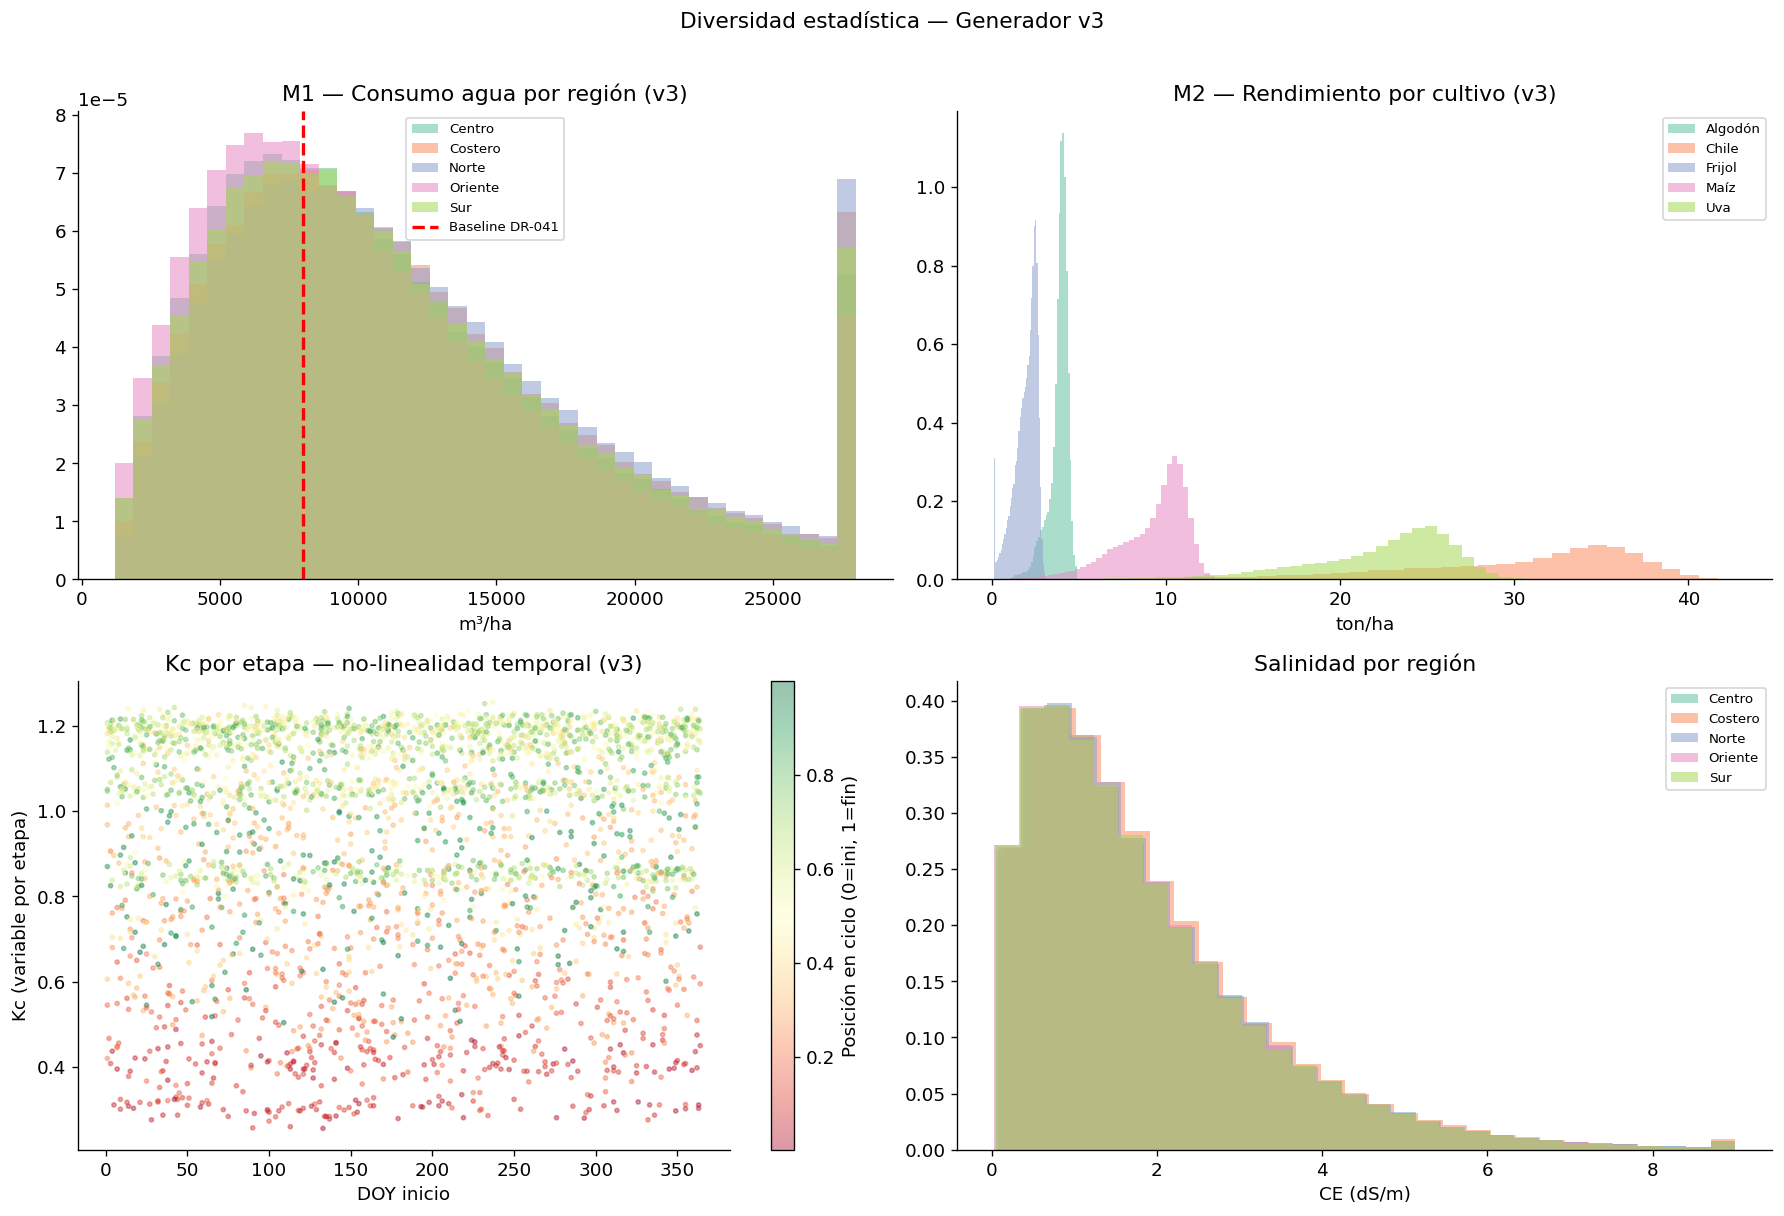

In [35]:
from scipy import stats as sp_stats

def entropia_bins(series, n_bins=20):
    counts, _ = np.histogram(series.dropna(), bins=n_bins)
    probs = counts[counts > 0] / counts.sum()
    return float(-np.sum(probs * np.log2(probs + 1e-12)))

def bimodality_coef(x):
    """Sarle's b > 0.555 = multimodal."""
    n = len(x); sk = sp_stats.skew(x); ku = sp_stats.kurtosis(x)
    return (sk**2 + 1) / (ku + 3 * (n-1)**2 / ((n-2)*(n-3)))

print("=" * 60)
print("COMBINACIONES ÚNICAS (5 dimensiones categóricas)")
print("=" * 60)
n_combos = df[["region","cultivo","tipo_suelo","sistema_riego","tipo_agricultor"]].drop_duplicates().shape[0]
print(f"  {n_combos} combinaciones únicas  (v2 tenía ~80)")

print()
print("=" * 60)
print("ENTROPÍA DE SHANNON (bits) — más = más diversidad")
print("=" * 60)
for feat in ["et0_promedio_mmdia","lluvia_total_mm","kc_promedio",
             "deficit_hidrico_frac","salinidad_ec_dsm","volumen_agua_total_m3_ha","rendimiento_real_ton_ha"]:
    h = entropia_bins(df[feat])
    print(f"  {feat:<35s}: {h:.2f} bits")

print()
print("=" * 60)
print("TASA DE EVENTOS EXTREMOS")
print("=" * 60)
for ev in ["ola_calor","helada","inundacion","plaga","falla_riego"]:
    print(f"  {ev:<20s}: {df[ev].mean():.1%}")

print()
print("=" * 60)
print("Kc std por cultivo (v2 ≈ 0.015 → v3 ≈ 0.25)")
print("=" * 60)
print(df.groupby("cultivo")["kc_promedio"].std().round(4).to_string())

# Visualización diversidad
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for reg, g in df.groupby("region"):
    axes[0,0].hist(g["volumen_agua_total_m3_ha"], bins=40, alpha=0.55, label=reg, density=True)
axes[0,0].axvline(8000, color="red", lw=2, ls="--", label="Baseline DR-041")
axes[0,0].set_xlabel("m³/ha"); axes[0,0].set_title("M1 — Consumo agua por región (v3)")
axes[0,0].legend(fontsize=8)

for cultivo, g in df.groupby("cultivo"):
    axes[0,1].hist(g["rendimiento_real_ton_ha"], bins=40, alpha=0.55, label=cultivo, density=True)
axes[0,1].set_xlabel("ton/ha"); axes[0,1].set_title("M2 — Rendimiento por cultivo (v3)")
axes[0,1].legend(fontsize=8)

sample = df.sample(min(3000, len(df)), random_state=42)
sc = axes[1,0].scatter(sample["doy_inicio"], sample["kc_promedio"],
                        c=sample["pos_ciclo_frac"], cmap="RdYlGn", alpha=0.4, s=6)
plt.colorbar(sc, ax=axes[1,0], label="Posición en ciclo (0=ini, 1=fin)")
axes[1,0].set_xlabel("DOY inicio"); axes[1,0].set_ylabel("Kc (variable por etapa)")
axes[1,0].set_title("Kc por etapa — no-linealidad temporal (v3)")

for reg, g in df.groupby("region"):
    axes[1,1].hist(g["salinidad_ec_dsm"], bins=30, alpha=0.55, label=reg, density=True)
axes[1,1].set_xlabel("CE (dS/m)"); axes[1,1].set_title("Salinidad por región")
axes[1,1].legend(fontsize=8)

plt.suptitle("Diversidad estadística — Generador v3", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2. Análisis exploratorio

In [36]:
print("Targets por cultivo:")
df.groupby("cultivo")[["volumen_agua_total_m3_ha","rendimiento_real_ton_ha"]].agg(
    ["mean","std","min","max"]).round(2)

Targets por cultivo:


volumen_agua_total_m3_ha                            \
                            mean      std     min      max   
cultivo                                                      
Algodón                 16131.80  7003.05  1200.0  28000.0   
Chile                    9301.53  4951.57  1200.0  28000.0   
Frijol                   8187.43  4493.79  1200.0  28000.0   
Maíz                    12239.97  6475.56  1200.0  28000.0   
Uva                     11612.47  6223.66  1200.0  28000.0   

        rendimiento_real_ton_ha                     
                           mean   std   min    max  
cultivo                                             
Algodón                    3.83  0.56  0.62   4.88  
Chile                     30.03  7.26  0.46  42.70  
Frijol                     1.94  0.64  0.12   3.05  
Maíz                       9.23  2.01  0.41  12.81  
Uva                       22.32  4.28  2.28  30.50

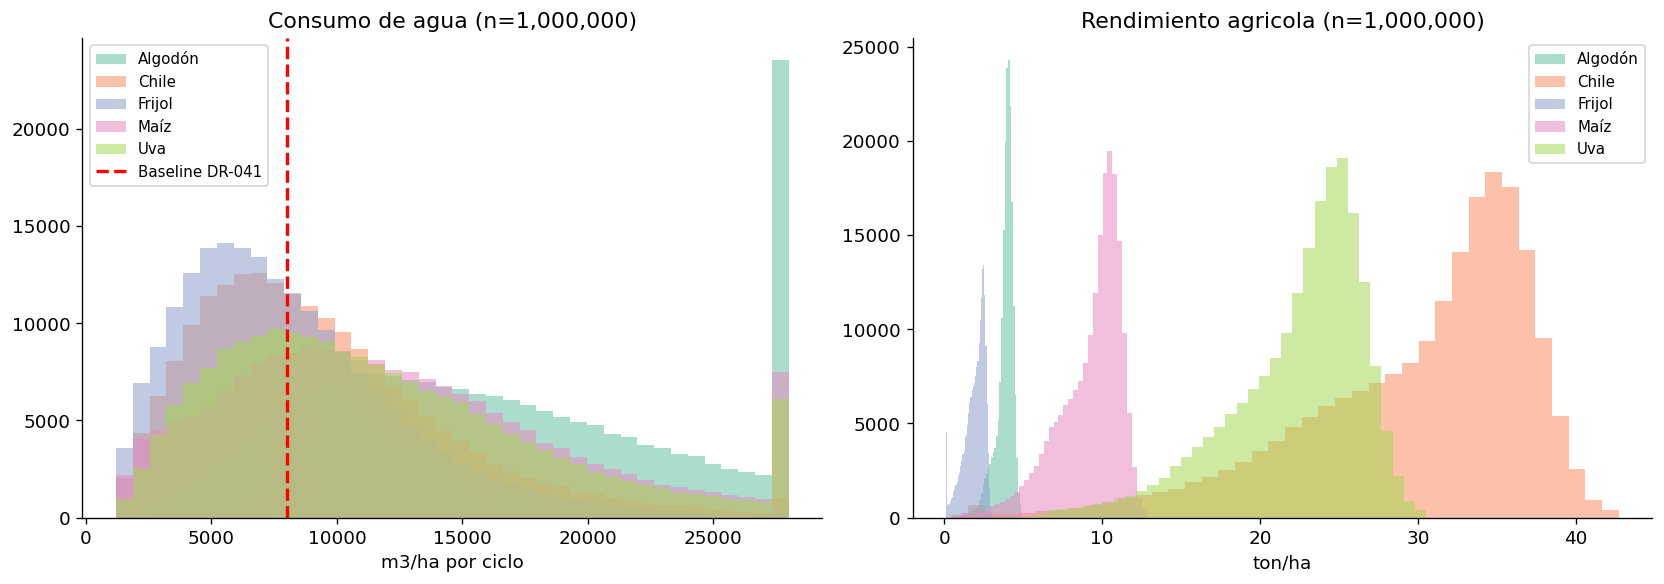

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cultivo, g in df.groupby("cultivo"):
    axes[0].hist(g["volumen_agua_total_m3_ha"], bins=40, alpha=0.55, label=cultivo)
axes[0].axvline(8000, color="red", lw=2, ls="--", label="Baseline DR-041")
axes[0].set_xlabel("m3/ha por ciclo"); axes[0].set_title(f"Consumo de agua (n={N_SAMPLES:,})")
axes[0].legend(fontsize=9)

for cultivo, g in df.groupby("cultivo"):
    axes[1].hist(g["rendimiento_real_ton_ha"], bins=40, alpha=0.55, label=cultivo)
axes[1].set_xlabel("ton/ha"); axes[1].set_title(f"Rendimiento agricola (n={N_SAMPLES:,})")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

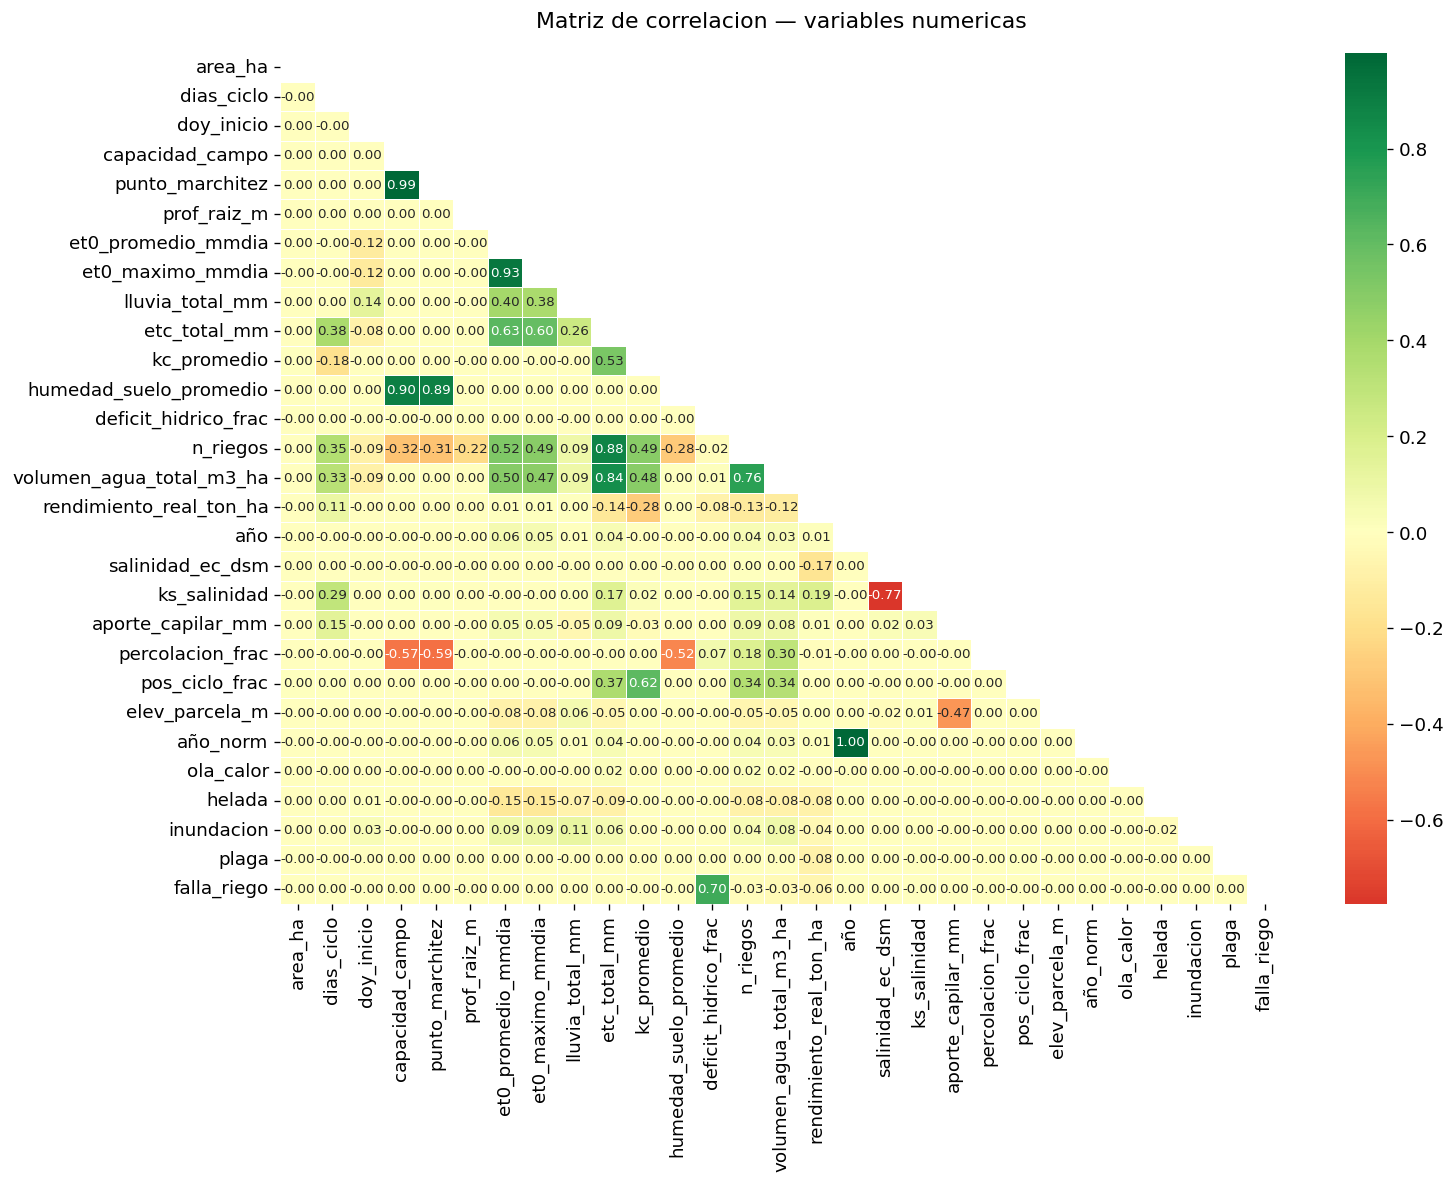

In [38]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 8})
ax.set_title("Matriz de correlacion — variables numericas", pad=15)
plt.tight_layout(); plt.show()

## 3. Feature Engineering

| Feature | Formula | Interpretacion |
|---------|---------|----------------|
| `eto_x_dias` | ET0_prom x dias_ciclo | Demanda evapotranspirativa total |
| `deficit_agua_mm` | ETc - lluvia (>=0) | Agua que debe reponer el riego |
| `agua_disponible_mm` | (CC-PMP) x prof x 1000 | Capacidad de retencion del suelo |
| `ky_cultivo` | lookup FAO-56 | Sensibilidad al deficit hidrico |
| `indice_estres_x_ky` | deficit_frac x Ky | Impacto potencial en rendimiento (FAO-33) |
| `doy_sin / doy_cos` | sin/cos(2pi*DOY/365) | Estacionalidad sin discontinuidad |
| `ciclo_sin/cos` | sin/cos(2pi*pos_ciclo) | Posición en ciclo (v3) |
| `estres_combinado` | deficit x (1-ks_sal) | Estrés hídrico + salino combinado (v3) |
| `deficit_neto_mm` | deficit - aporte_capilar | Déficit real tras ascenso capilar (v3) |

In [39]:
KY_MAP = {"Maíz":1.25, "Frijol":1.15, "Algodón":0.85, "Uva":0.85, "Chile":1.10}
EF_MAP = {"gravedad":0.50, "aspersion":0.75, "goteo":0.90, "microaspersion":0.85}

# Features v2 (sin cambio)
df["eto_x_dias"]          = df["et0_promedio_mmdia"] * df["dias_ciclo"]
df["deficit_agua_mm"]     = (df["etc_total_mm"] - df["lluvia_total_mm"]).clip(lower=0)
df["agua_disponible_mm"]  = (df["capacidad_campo"] - df["punto_marchitez"]) * df["prof_raiz_m"] * 1000
df["ky_cultivo"]          = df["cultivo"].map(KY_MAP)
df["eficiencia_sistema"]  = df["sistema_riego"].map(EF_MAP)
df["indice_estres_x_ky"]  = df["deficit_hidrico_frac"] * df["ky_cultivo"]
df["doy_sin"]             = np.sin(2 * np.pi * df["doy_inicio"] / 365)
df["doy_cos"]             = np.cos(2 * np.pi * df["doy_inicio"] / 365)
df["ratio_demanda_suelo"] = (df["etc_total_mm"] / df["agua_disponible_mm"].replace(0, np.nan)).fillna(1.0)

# Features v3 adicionales
df["ciclo_sin"]       = np.sin(2 * np.pi * df["pos_ciclo_frac"])
df["ciclo_cos"]       = np.cos(2 * np.pi * df["pos_ciclo_frac"])
df["estres_combinado"]= df["deficit_hidrico_frac"] * (1 - df["ks_salinidad"])
df["deficit_neto_mm"] = (df["deficit_agua_mm"] - df["aporte_capilar_mm"]).clip(lower=0)
df["m3_por_riego"]    = (df["volumen_agua_total_m3_ha"] / df["n_riegos"].replace(0,1)).round(2)
df["año_norm_feat"]   = df["año_norm"]

event_cols = ["ola_calor","helada","inundacion","plaga","falla_riego"]
df["evento_extremo"]  = (df[event_cols].sum(axis=1) > 0).astype(np.int8)

n_v2 = 9; n_v3 = 7
print(f"Features derivadas: {n_v2} v2 + {n_v3} v3 = {n_v2+n_v3} total")

Features derivadas: 9 v2 + 7 v3 = 16 total


## 4. Preparacion ML

In [40]:
cat_cols = ["cultivo", "tipo_suelo", "sistema_riego"]
for col_v3 in ["region", "tipo_agricultor"]:
    if col_v3 in df.columns:
        cat_cols.append(col_v3)

le_dict = {}
df_enc  = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}") 

cultivo: {'Algodón': np.int64(0), 'Chile': np.int64(1), 'Frijol': np.int64(2), 'Maíz': np.int64(3), 'Uva': np.int64(4)}
tipo_suelo: {'arcilloso': np.int64(0), 'franco': np.int64(1), 'franco-arcilloso': np.int64(2), 'franco-arenoso': np.int64(3)}
sistema_riego: {'aspersion': np.int64(0), 'goteo': np.int64(1), 'gravedad': np.int64(2), 'microaspersion': np.int64(3)}
region: {'Centro': np.int64(0), 'Costero': np.int64(1), 'Norte': np.int64(2), 'Oriente': np.int64(3), 'Sur': np.int64(4)}
tipo_agricultor: {'conservador': np.int64(0), 'eficiente': np.int64(1), 'negligente': np.int64(2), 'tecnificado': np.int64(3)}


In [41]:
def _feat(col): return [col] if col in df_enc.columns else []

FEATURES_AGUA = [
    "cultivo","tipo_suelo","sistema_riego",
    *_feat("region"), *_feat("tipo_agricultor"),
    "area_ha","dias_ciclo","doy_inicio","doy_sin","doy_cos",
    "capacidad_campo","punto_marchitez","prof_raiz_m",
    "et0_promedio_mmdia","et0_maximo_mmdia","lluvia_total_mm",
    "etc_total_mm","kc_promedio","n_riegos",
    "eto_x_dias","deficit_agua_mm","agua_disponible_mm",
    "eficiencia_sistema","ratio_demanda_suelo",
    *_feat("salinidad_ec_dsm"), *_feat("aporte_capilar_mm"),
    *_feat("percolacion_frac"), *_feat("pos_ciclo_frac"),
    *_feat("ciclo_sin"), *_feat("ciclo_cos"),
    *_feat("elev_parcela_m"), *_feat("año_norm_feat"),
    *_feat("deficit_neto_mm"),
    *_feat("ola_calor"), *_feat("inundacion"),
    *_feat("falla_riego"), *_feat("evento_extremo"),
]

FEATURES_REND = [
    "cultivo","tipo_suelo","sistema_riego",
    *_feat("region"), *_feat("tipo_agricultor"),
    "area_ha","dias_ciclo","doy_inicio","doy_sin","doy_cos",
    "capacidad_campo","punto_marchitez","prof_raiz_m",
    "et0_promedio_mmdia","et0_maximo_mmdia","lluvia_total_mm",
    "etc_total_mm","kc_promedio",
    "humedad_suelo_promedio","deficit_hidrico_frac","n_riegos",
    "eto_x_dias","deficit_agua_mm","agua_disponible_mm",
    "ky_cultivo","indice_estres_x_ky","ratio_demanda_suelo",
    *_feat("salinidad_ec_dsm"), *_feat("ks_salinidad"),
    *_feat("aporte_capilar_mm"), *_feat("pos_ciclo_frac"),
    *_feat("ciclo_sin"), *_feat("ciclo_cos"),
    *_feat("año_norm_feat"), *_feat("estres_combinado"),
    *_feat("elev_parcela_m"),
    *_feat("ola_calor"), *_feat("helada"),
    *_feat("inundacion"), *_feat("plaga"),
    *_feat("falla_riego"), *_feat("evento_extremo"),
]

TARGET_AGUA = "volumen_agua_total_m3_ha"
TARGET_REND = "rendimiento_real_ton_ha"

X_agua = df_enc[FEATURES_AGUA]; y_agua = df_enc[TARGET_AGUA]
X_rend = df_enc[FEATURES_REND]; y_rend = df_enc[TARGET_REND]

X_agua_tr, X_agua_te, y_agua_tr, y_agua_te = train_test_split(
    X_agua, y_agua, test_size=0.20, random_state=SEED, stratify=df_enc["cultivo"])
X_rend_tr, X_rend_te, y_rend_tr, y_rend_te = train_test_split(
    X_rend, y_rend, test_size=0.20, random_state=SEED, stratify=df_enc["cultivo"])

print(f"Train: {X_agua_tr.shape[0]:,} | Test: {X_agua_te.shape[0]:,}")
print(f"Features M1: {len(FEATURES_AGUA)} | Features M2: {len(FEATURES_REND)}")

Train: 800,000 | Test: 200,000
Features M1: 37 | Features M2: 42


## 5. Visualizacion SHAP (XGBoost nativo, sin paquete shap)

XGBoost 2.x/3.x calcula valores SHAP directamente con `predict(pred_contribs=True)`.

**Fix v3:** se añade `iteration_range=(0, best_iteration+1)` para que los SHAP values
correspondan exactamente al mismo modelo que usa `model.predict()`. Sin esto, con early
stopping los valores SHAP se calculan sobre TODOS los árboles (incluyendo los overfitted),
mientras `predict()` usa solo los mejores → valores SHAP incoherentes con las predicciones.

La función `verificar_shap()` confirma automáticamente que el error es <0.01%.

In [42]:
def plot_shap_summary(shap_vals, X, feature_names, title="SHAP Summary", top_n=15, color="#5b8db8"):
    """Beeswarm SHAP plot — matplotlib puro, robusto a DataFrame y numpy."""
    mean_abs = np.abs(shap_vals).mean(axis=0)
    order    = np.argsort(mean_abs)[-top_n:]
    shap_sel = shap_vals[:, order]
    feat_sel = np.array(feature_names)[order]
    # Siempre convertir a numpy — evita ambigüedad con indexing de DataFrames
    X_arr     = X.values if hasattr(X, 'values') else np.asarray(X)
    feat_vals = X_arr[:, order].astype(float)
    feat_norm = feat_vals.copy()
    for j in range(feat_norm.shape[1]):
        col = feat_norm[:, j]; r = col.max() - col.min()
        feat_norm[:, j] = (col - col.min()) / r if r > 0 else 0.5
    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.45)))
    cmap = plt.cm.RdYlBu_r
    for idx in range(shap_sel.shape[1]):
        y_jitter = idx + np.random.uniform(-0.3, 0.3, len(shap_sel))
        ax.scatter(shap_sel[:, idx], y_jitter, c=feat_norm[:, idx],
                   cmap=cmap, alpha=0.25, s=8, linewidths=0)
    ax.set_yticks(range(len(feat_sel))); ax.set_yticklabels(feat_sel, fontsize=10)
    ax.axvline(0, color="gray", lw=0.8, ls="--")
    ax.set_xlabel("Valor SHAP (impacto en prediccion)"); ax.set_title(title)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Valor del feature (bajo → alto)", fontsize=9)
    plt.tight_layout(); plt.show()


def get_shap_vals(model, X, feature_names):
    """
    Extrae SHAP values via XGBoost nativo pred_contribs=True.

    FIX CRÍTICO: usa iteration_range=(0, best_iteration+1) para que los
    SHAP values correspondan EXACTAMENTE al mismo modelo que usa model.predict().
    Sin esto, con early stopping el booster usa TODOS los árboles (incluyendo
    los overfitted) mientras predict() usa solo los mejores → valores SHAP
    incoherentes, max_diff > 10,000 m³/ha.
    """
    best_iter  = getattr(model, 'best_iteration', None)
    iter_range = (0, best_iter + 1) if best_iter is not None and best_iter > 0 else None
    X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
    dmat  = xgb.DMatrix(X_arr, feature_names=feature_names)
    if iter_range is not None:
        raw = model.get_booster().predict(dmat, pred_contribs=True, iteration_range=iter_range)
    else:
        raw = model.get_booster().predict(dmat, pred_contribs=True)
    return raw[:, :-1]   # descartar bias (ultima columna)


def verificar_shap(model, X, feature_names, nombre="modelo", tol_rel=0.05):
    """Sanity check: SHAP values + bias ≈ model.predict(). Error esperado < 0.01%."""
    best_iter  = getattr(model, 'best_iteration', None)
    iter_range = (0, best_iter + 1) if best_iter is not None and best_iter > 0 else None
    X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
    dmat  = xgb.DMatrix(X_arr, feature_names=feature_names)
    raw   = model.get_booster().predict(dmat, pred_contribs=True,
                                         **({"iteration_range": iter_range} if iter_range else {}))
    shap_sum   = raw.sum(axis=1)
    pred_model = model.predict(X)
    max_diff   = np.abs(shap_sum - pred_model).max()
    rel_err    = max_diff / (np.abs(pred_model).mean() + 1e-8)
    status     = "✓ OK" if rel_err < tol_rel else "✗ FALLO"
    print(f"  SHAP check [{nombre}]: max_diff={max_diff:.4f} | rel_err={rel_err:.6%} | {status}")
    return rel_err < tol_rel


print("Funciones SHAP listas (iteration_range corregido para early stopping)")

Funciones SHAP listas (iteration_range corregido para early stopping)


## 6. Modelo 1 — Consumo de Agua

XGBoost construye un ensamble aditivo de arboles con regularizacion L1/L2.
**Early stopping**: detiene el entrenamiento cuando el RMSE de validacion
no mejora en 50 rondas consecutivas — no es necesario tunear `n_estimators` a mano.

In [43]:
def metricas(y_true, y_pred, nombre, tarifa=1.68):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{'─'*52}")
    print(f"  {nombre}")
    print(f"  MAE   = {mae:>10.2f}")
    print(f"  RMSE  = {rmse:>10.2f}")
    print(f"  R2    = {r2:>10.4f}")
    if "agua" in nombre.lower():
        print(f"  Error monetario = ${rmse*tarifa:,.0f} MXN/ha/ciclo")
    print(f"{'─'*52}")
    return {"mae":mae, "rmse":rmse, "r2":r2}

In [44]:
X_agua_tr2, X_agua_val, y_agua_tr2, y_agua_val = train_test_split(
    X_agua_tr, y_agua_tr, test_size=0.10, random_state=SEED)

params_agua = dict(
    n_estimators=2000, max_depth=5, learning_rate=0.05,
    subsample=0.80, colsample_bytree=0.80, min_child_weight=3,
    reg_alpha=0.10, reg_lambda=1.00,
    early_stopping_rounds=50, eval_metric="rmse",
    random_state=SEED, n_jobs=-1, verbosity=0,
)

t0 = time.time()
model_agua = xgb.XGBRegressor(**params_agua)
model_agua.fit(X_agua_tr2, y_agua_tr2,
               eval_set=[(X_agua_val, y_agua_val)], verbose=False)
elapsed = time.time() - t0

pred_agua = model_agua.predict(X_agua_te)
met_agua  = metricas(y_agua_te, pred_agua, "M1 — Consumo de agua (m3/ha)")
print(f"Entrenamiento: {elapsed:.1f}s | Best iter: {model_agua.best_iteration}")

────────────────────────────────────────────────────
  M1 — Consumo de agua (m3/ha)
  MAE   =     905.76
  RMSE  =    1335.11
  R2    =     0.9579
  Error monetario = $2,243 MXN/ha/ciclo
────────────────────────────────────────────────────
Entrenamiento: 26.6s | Best iter: 320


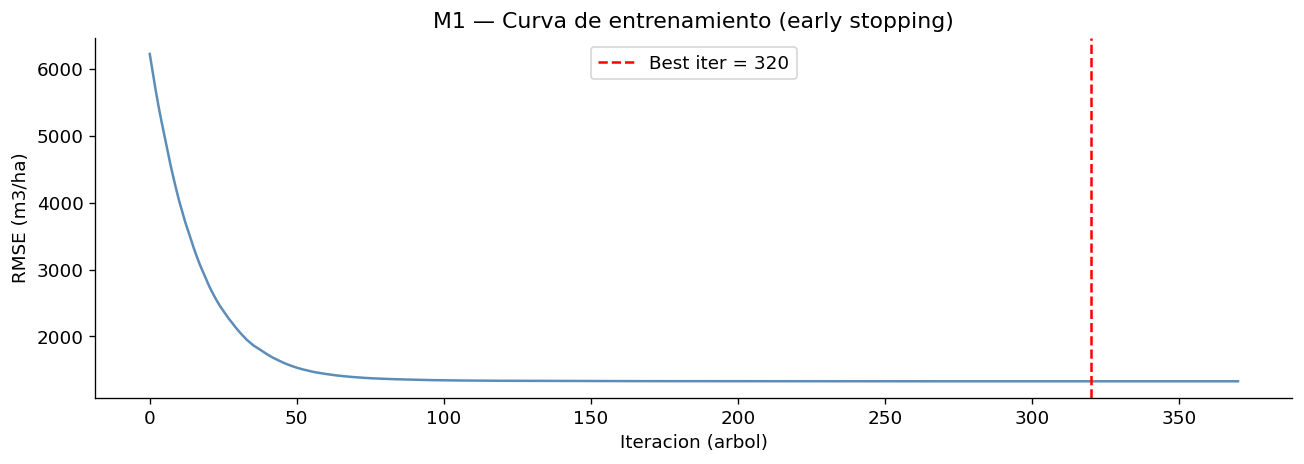

In [45]:
evals_agua = model_agua.evals_result().get("validation_0", {}).get("rmse", [])
if evals_agua:
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(evals_agua, color="#5b8db8", lw=1.5)
    ax.axvline(model_agua.best_iteration, color="red", ls="--", lw=1.5,
               label=f"Best iter = {model_agua.best_iteration}")
    ax.set_xlabel("Iteracion (arbol)"); ax.set_ylabel("RMSE (m3/ha)")
    ax.set_title("M1 — Curva de entrenamiento (early stopping)")
    ax.legend(); plt.tight_layout(); plt.show()

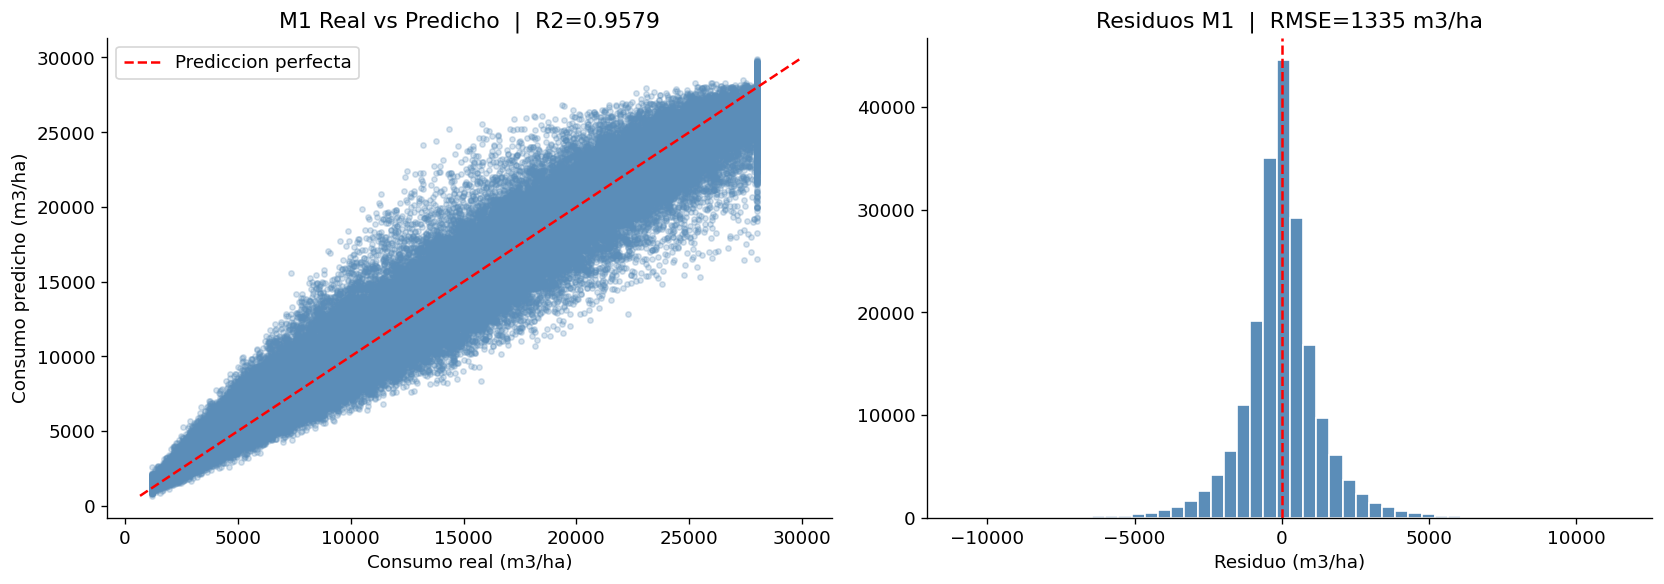


Sesgo por rango de consumo:
                          n  error_medio (m3/ha)    RMSE
bin                                                     
(1173.2, 6560.0]    50261.0                199.0   691.0
(6560.0, 11920.0]   70726.0                146.0  1131.0
(11920.0, 17280.0]  42796.0                 -3.0  1577.0
(17280.0, 22640.0]  20310.0               -252.0  1938.0
(22640.0, 28000.0]  15907.0               -886.0  1932.0


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_agua_te, pred_agua, alpha=0.25, s=10, color="#5b8db8")
lims = [min(y_agua_te.min(), pred_agua.min()), max(y_agua_te.max(), pred_agua.max())]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Prediccion perfecta")
axes[0].set_xlabel("Consumo real (m3/ha)"); axes[0].set_ylabel("Consumo predicho (m3/ha)")
axes[0].set_title(f"M1 Real vs Predicho  |  R2={met_agua['r2']:.4f}"); axes[0].legend()

res = y_agua_te.values - pred_agua
axes[1].hist(res, bins=50, color="#5b8db8", edgecolor="white")
axes[1].axvline(0, color="red", lw=1.5, ls="--")
axes[1].set_xlabel("Residuo (m3/ha)"); axes[1].set_title(f"Residuos M1  |  RMSE={met_agua['rmse']:.0f} m3/ha")

plt.tight_layout(); plt.show()

bins_real = pd.cut(y_agua_te, bins=5)
sesgo = pd.DataFrame({"real":y_agua_te, "pred":pred_agua, "bin":bins_real})
print("\nSesgo por rango de consumo:")
print(sesgo.groupby("bin", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "error_medio (m3/ha)": round((g["pred"]-g["real"]).mean(), 0),
        "RMSE": round(np.sqrt(mean_squared_error(g["real"],g["pred"])), 0)
    })
))

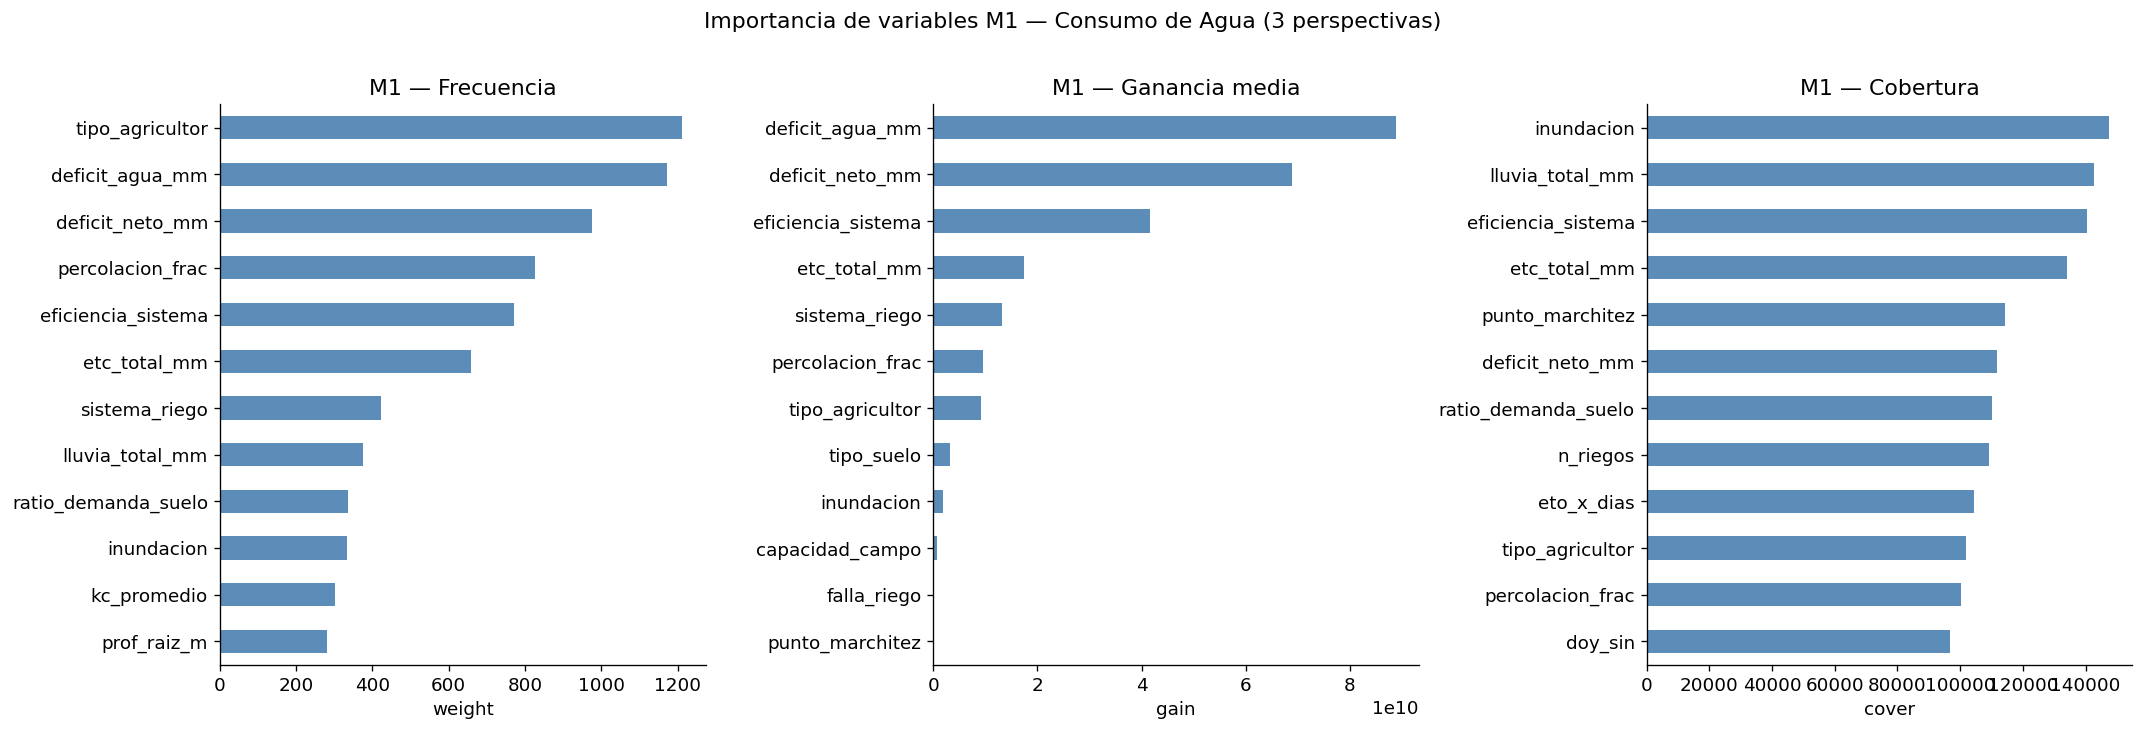

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
imp_types = [("weight","Frecuencia"), ("gain","Ganancia media"), ("cover","Cobertura")]

for ax, (itype, ilabel) in zip(axes, imp_types):
    scores = model_agua.get_booster().get_score(importance_type=itype)
    series = pd.Series(scores).sort_values(ascending=True).tail(12)
    series.plot(kind="barh", ax=ax, color="#5b8db8")
    ax.set_title(f"M1 — {ilabel}"); ax.set_xlabel(itype)

plt.suptitle("Importancia de variables M1 — Consumo de Agua (3 perspectivas)", y=1.01)
plt.tight_layout(); plt.show()

  SHAP check [M1 Agua]: max_diff=0.0410 | rel_err=0.000357% | ✓ OK


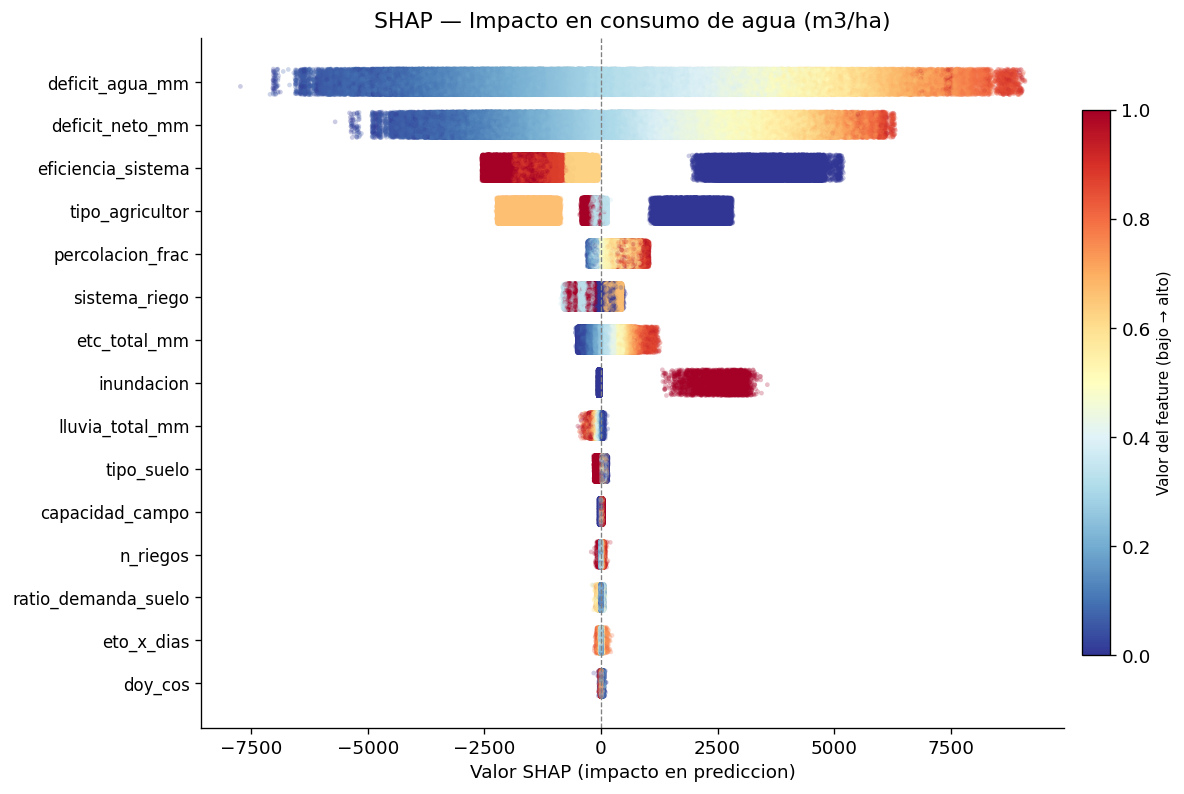

In [48]:
shap_agua = get_shap_vals(model_agua, X_agua_te, FEATURES_AGUA)
verificar_shap(model_agua, X_agua_te, FEATURES_AGUA, nombre="M1 Agua")

plot_shap_summary(
    shap_agua, X_agua_te, FEATURES_AGUA,
    title="SHAP — Impacto en consumo de agua (m3/ha)", top_n=15,
)

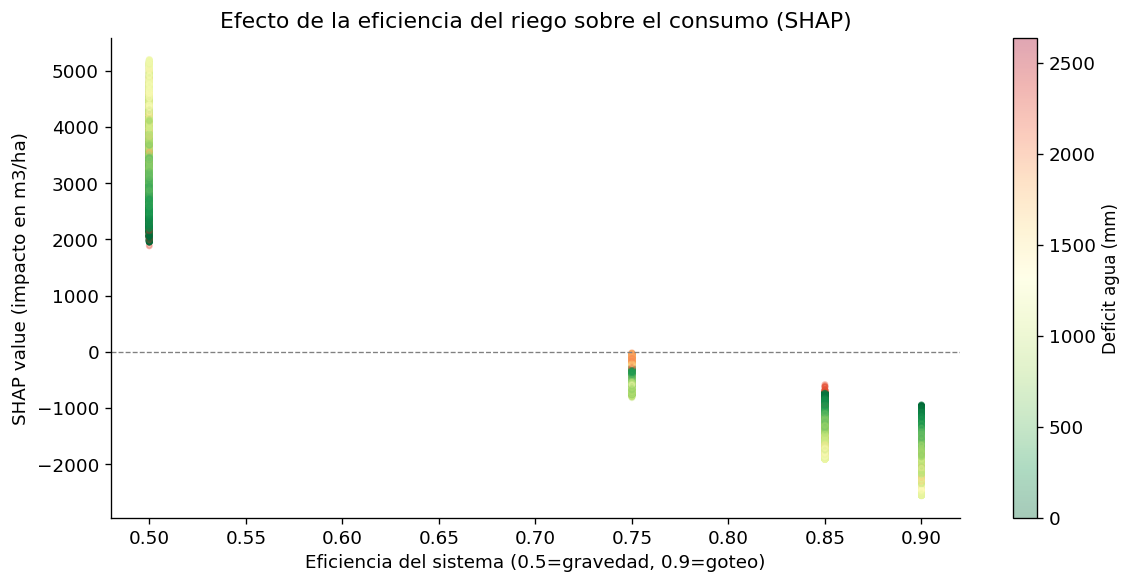

In [49]:
idx_ef  = FEATURES_AGUA.index("eficiencia_sistema")
idx_def = FEATURES_AGUA.index("deficit_agua_mm")
X_agua_te_arr = X_agua_te.values

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(X_agua_te_arr[:, idx_ef], shap_agua[:, idx_ef],
                c=X_agua_te_arr[:, idx_def], cmap="RdYlGn_r", alpha=0.35, s=10)
plt.colorbar(sc, ax=ax).set_label("Deficit agua (mm)", fontsize=10)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Eficiencia del sistema (0.5=gravedad, 0.9=goteo)")
ax.set_ylabel("SHAP value (impacto en m3/ha)")
ax.set_title("Efecto de la eficiencia del riego sobre el consumo (SHAP)")
plt.tight_layout(); plt.show()

## 7. Curvas de aprendizaje — cuantos datos necesitamos realmente?

Con el generador v3 la curva debería seguir descendiendo más allá de 50k muestras
(vs v2 que aplanaba a ~20-30k). Si aplana igual de rápido, el problema está en que
la estructura de features sigue siendo muy predecible.

Calculando curvas de aprendizaje (puede tomar ~1-2 min)...


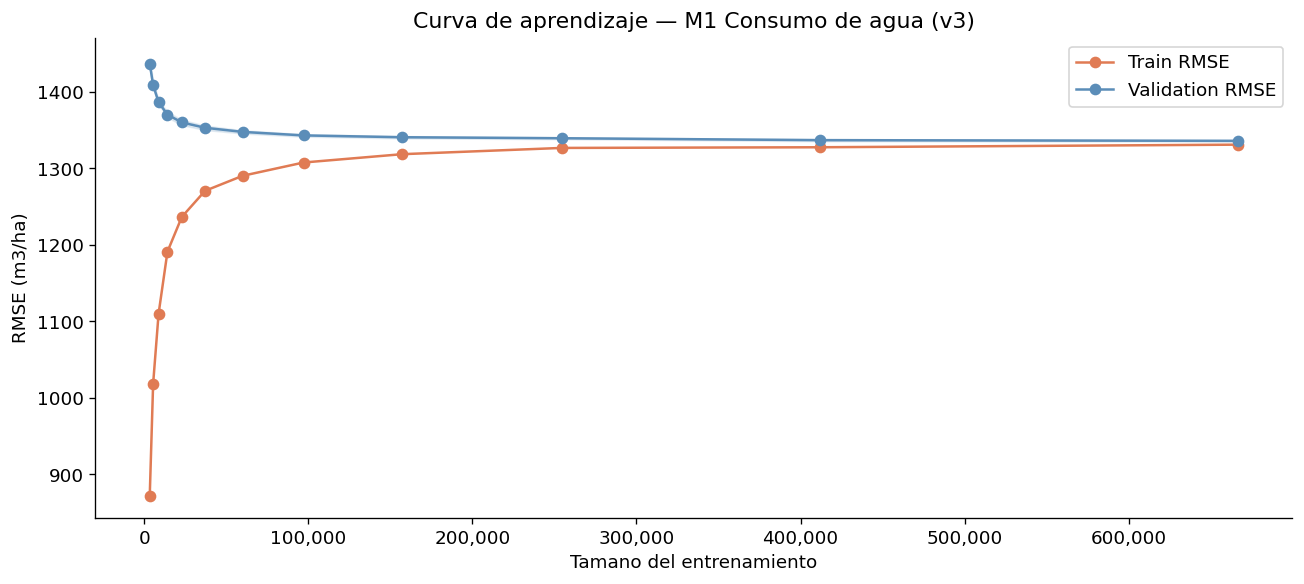

RMSE con  5% (8,734 muestras): 1386.4 m3/ha
RMSE con 50% (254,412 muestras): 1339.4 m3/ha
RMSE con 100% (666,666 muestras): 1336.0 m3/ha


In [50]:
print("Calculando curvas de aprendizaje (puede tomar ~1-2 min)...")

lc_params = dict(n_estimators=200, max_depth=5, learning_rate=0.05,
                 subsample=0.80, colsample_bytree=0.80,
                 random_state=SEED, n_jobs=-1, verbosity=0)

train_sizes, train_scores, val_scores = learning_curve(
    xgb.XGBRegressor(**lc_params), X_agua, y_agua,
    train_sizes=np.logspace(np.log10(0.005), 0, 12),
    cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=SEED,
)

tr_rmse  = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train_sizes, tr_rmse,  "o-", color="#e07b54", label="Train RMSE")
ax.plot(train_sizes, val_rmse, "o-", color="#5b8db8", label="Validation RMSE")
ax.fill_between(train_sizes, val_rmse-val_std, val_rmse+val_std, alpha=0.15, color="#5b8db8")
ax.set_xlabel("Tamano del entrenamiento"); ax.set_ylabel("RMSE (m3/ha)")
ax.set_title("Curva de aprendizaje — M1 Consumo de agua (v3)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
ax.legend(); plt.tight_layout(); plt.show()

print(f"RMSE con  5% ({train_sizes[2]:,.0f} muestras): {val_rmse[2]:.1f} m3/ha")
print(f"RMSE con 50% ({train_sizes[-3]:,.0f} muestras): {val_rmse[-3]:.1f} m3/ha")
print(f"RMSE con 100% ({train_sizes[-1]:,.0f} muestras): {val_rmse[-1]:.1f} m3/ha")

## 8. Modelo 2 — Rendimiento Agricola

Base agronómica FAO-33: XGBoost aprende la relación rendimiento/estrés hídrico
junto con efectos de suelo, clima y sistema de riego sin programarla explícitamente.
En v3, el estrés por salinidad actúa como confusor independiente que aumenta la
complejidad del target.

In [51]:
X_rend_tr2, X_rend_val, y_rend_tr2, y_rend_val = train_test_split(
    X_rend_tr, y_rend_tr, test_size=0.10, random_state=SEED)

params_rend = dict(
    n_estimators=2000, max_depth=4, learning_rate=0.04,
    subsample=0.80, colsample_bytree=0.75, min_child_weight=5,
    reg_alpha=0.05, reg_lambda=1.50,
    early_stopping_rounds=50, eval_metric="rmse",
    random_state=SEED, n_jobs=-1, verbosity=0,
)

t0 = time.time()
model_rend = xgb.XGBRegressor(**params_rend)
model_rend.fit(X_rend_tr2, y_rend_tr2,
               eval_set=[(X_rend_val, y_rend_val)], verbose=False)
elapsed = time.time() - t0

pred_rend = model_rend.predict(X_rend_te)
met_rend  = metricas(y_rend_te, pred_rend, "M2 — Rendimiento agricola (ton/ha)")
print(f"Entrenamiento: {elapsed:.1f}s | Best iter: {model_rend.best_iteration}")

────────────────────────────────────────────────────
  M2 — Rendimiento agricola (ton/ha)
  MAE   =       0.84
  RMSE  =       1.39
  R2    =     0.9856
────────────────────────────────────────────────────
Entrenamiento: 145.1s | Best iter: 1990


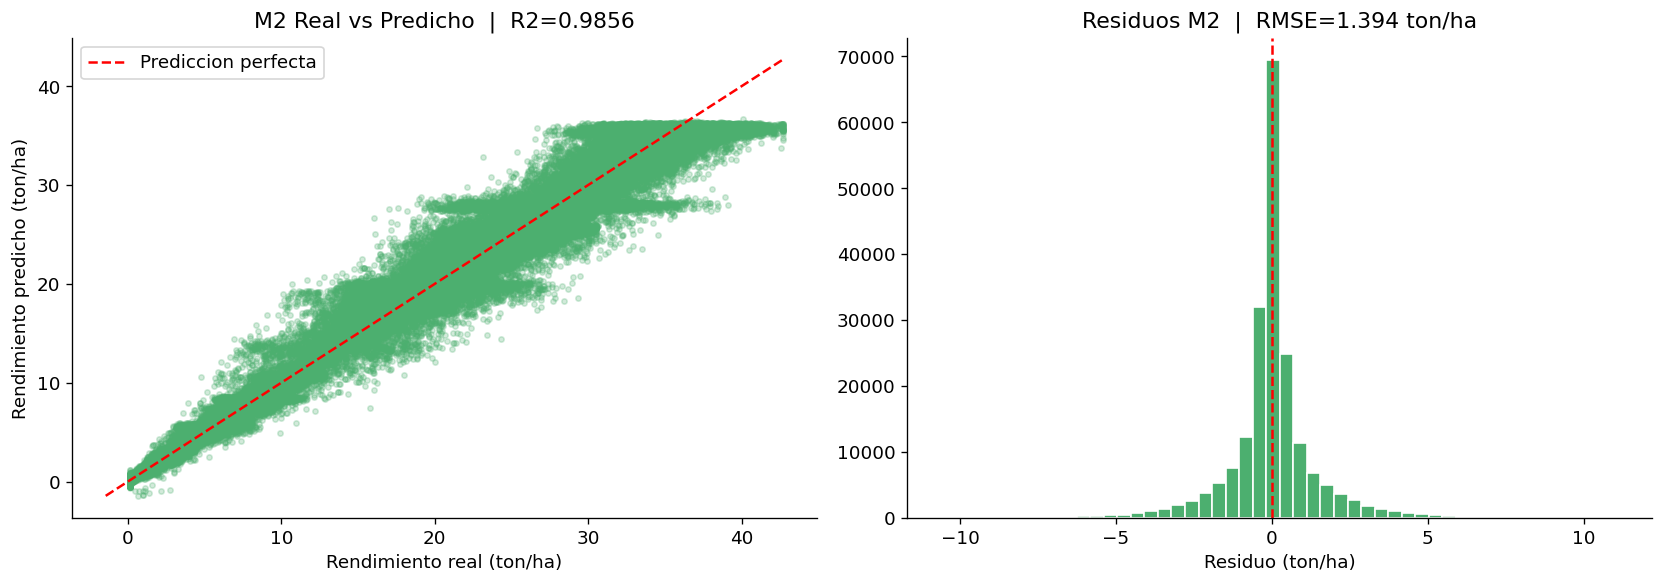

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_rend_te, pred_rend, alpha=0.25, s=10, color="#4caf6f")
lims = [min(y_rend_te.min(), pred_rend.min()), max(y_rend_te.max(), pred_rend.max())]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Prediccion perfecta")
axes[0].set_xlabel("Rendimiento real (ton/ha)"); axes[0].set_ylabel("Rendimiento predicho (ton/ha)")
axes[0].set_title(f"M2 Real vs Predicho  |  R2={met_rend['r2']:.4f}"); axes[0].legend()

res_r = y_rend_te.values - pred_rend
axes[1].hist(res_r, bins=50, color="#4caf6f", edgecolor="white")
axes[1].axvline(0, color="red", lw=1.5, ls="--")
axes[1].set_xlabel("Residuo (ton/ha)"); axes[1].set_title(f"Residuos M2  |  RMSE={met_rend['rmse']:.3f} ton/ha")

plt.tight_layout(); plt.show()

  SHAP check [M2 Rendimiento]: max_diff=0.0001 | rel_err=0.001020% | ✓ OK


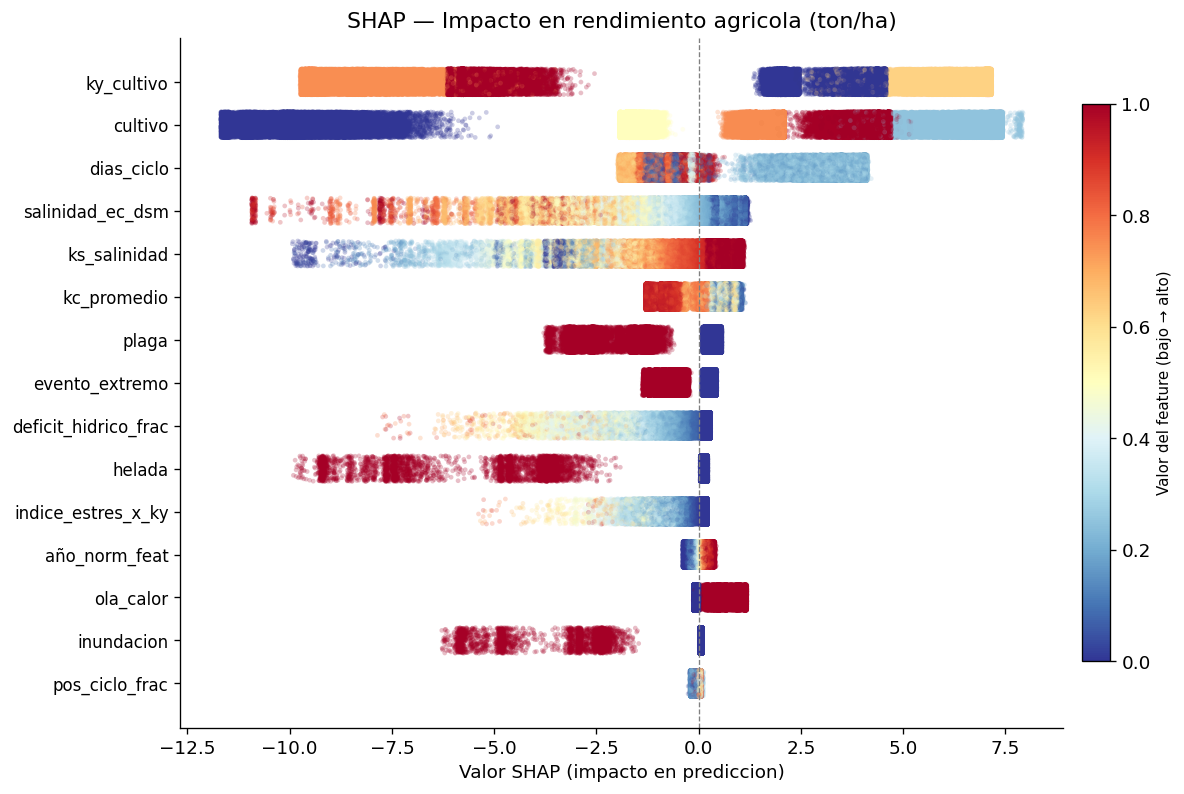

In [53]:
shap_rend = get_shap_vals(model_rend, X_rend_te, FEATURES_REND)
verificar_shap(model_rend, X_rend_te, FEATURES_REND, nombre="M2 Rendimiento")

plot_shap_summary(
    shap_rend, X_rend_te, FEATURES_REND,
    title="SHAP — Impacto en rendimiento agricola (ton/ha)",
    top_n=15, color="#4caf6f",
)

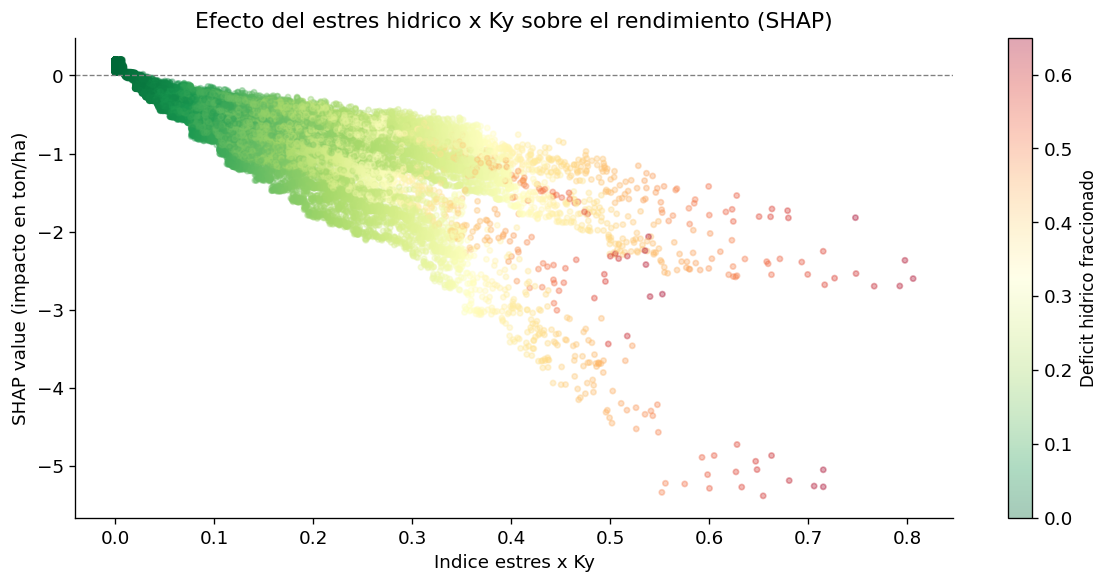

In [54]:
idx_estres  = FEATURES_REND.index("indice_estres_x_ky")
idx_deficit = FEATURES_REND.index("deficit_hidrico_frac")
X_rend_te_arr = X_rend_te.values

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(X_rend_te_arr[:, idx_estres], shap_rend[:, idx_estres],
                c=X_rend_te_arr[:, idx_deficit], cmap="RdYlGn_r", alpha=0.35, s=10)
plt.colorbar(sc, ax=ax).set_label("Deficit hidrico fraccionado", fontsize=10)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Indice estres x Ky"); ax.set_ylabel("SHAP value (impacto en ton/ha)")
ax.set_title("Efecto del estres hidrico x Ky sobre el rendimiento (SHAP)")
plt.tight_layout(); plt.show()

## 9. [OPCIONAL] Optimizacion de hiperparametros con Optuna

Requiere: `pip install optuna`
Descomenta la celda para ejecutar búsqueda bayesiana (~50 trials, ~5-10 min).

In [ ]:
import optuna
import numpy as np
import xgboost as xgb

from sklearn.metrics import mean_squared_error

try:
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    N_HPO = min(20_000, len(X_agua_tr2))

    idx = np.random.choice(len(X_agua_tr2), N_HPO, replace=False)

    X_hpo = X_agua_tr2.iloc[idx]
    y_hpo = y_agua_tr2.iloc[idx]

    def objective(trial):

        p = {
            "n_estimators": 500,
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("lr", 0.01, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
            "random_state": SEED,
            "n_jobs": -1,
            "verbosity": 0,
        }

        m = xgb.XGBRegressor(**p)

        m.fit(
            X_hpo,
            y_hpo,
            eval_set=[(X_agua_val, y_agua_val)],
            verbose=False,
        )

        pred = m.predict(X_agua_val)

        rmse = np.sqrt(mean_squared_error(y_agua_val, pred))

        return rmse

    study = optuna.create_study(direction="minimize")

    study.optimize(
        objective,
        n_trials=50,
        show_progress_bar=True
    )

    print("Mejores params:")
    print(study.best_params)

    print(f"RMSE: {study.best_value:.2f} m3/ha")

except ImportError:
    print("[OMITIDO] Optuna no instalado. Ejecuta: pip install optuna")
except Exception as e:
    print(f"[ERROR] Optuna fallo: {e}")


  0%|          | 0/50 [00:00<?, ?it/s]

## 10. Comparacion final e impacto economico

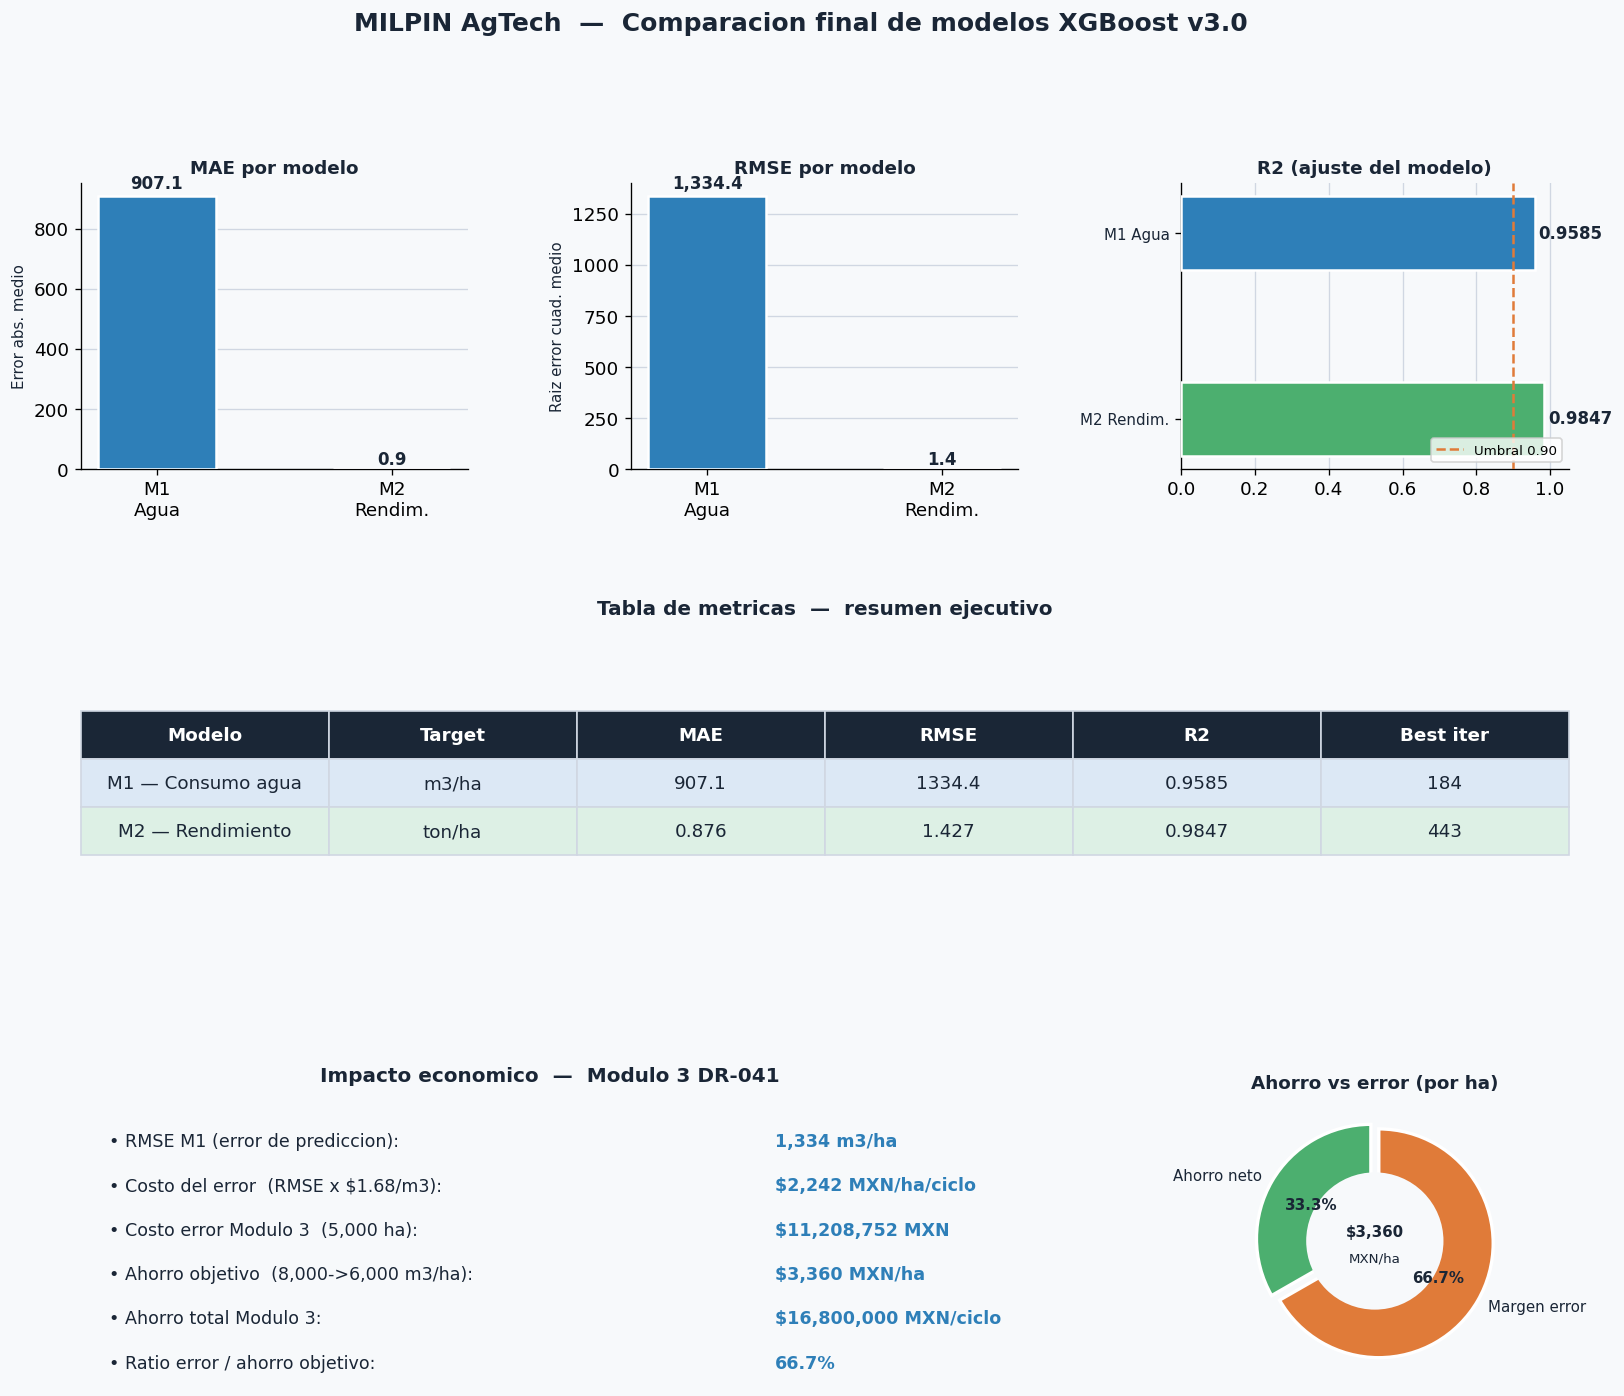


[OK] Figura guardada: milpin_resumen_final.png
           Modelo Target     MAE     RMSE     R2  Best iter
M1 — Consumo agua  m3/ha 907.100 1334.400 0.9585        184
 M2 — Rendimiento ton/ha   0.876    1.427 0.9847        443


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

TARIFA  = 1.68    # MXN/m3, CFE 9-CU bombeo 80m
HA_MOD3 = 5_000   # ha estimadas Modulo 3 DR-041

# ── Tabla resumen ─────────────────────────────────────────────────────────────
resumen = pd.DataFrame({
    "Modelo":    ["M1 — Consumo agua", "M2 — Rendimiento"],
    "Target":    ["m3/ha",             "ton/ha"],
    "MAE":       [round(met_agua["mae"], 1), round(met_rend["mae"], 3)],
    "RMSE":      [round(met_agua["rmse"], 1), round(met_rend["rmse"], 3)],
    "R2":        [round(met_agua["r2"], 4),   round(met_rend["r2"], 4)],
    "Best iter": [model_agua.best_iteration,  model_rend.best_iteration],
})

# Impacto economico
costo_rmse   = met_agua["rmse"] * TARIFA
ahorro_obj   = (8_000 - 6_000) * TARIFA
ratio        = costo_rmse / ahorro_obj
ahorro_total = ahorro_obj * HA_MOD3

# ── Paleta corporativa ────────────────────────────────────────────────────────
C_AGUA = "#2e7fb8"
C_REND = "#4caf6f"
C_BG   = "#f7f9fb"
C_DARK = "#1a2636"
C_WARN = "#e07b39"
C_LINE = "#d0d7e2"

fig = plt.figure(figsize=(16, 13), facecolor=C_BG)
fig.suptitle(
    "MILPIN AgTech  —  Comparacion final de modelos XGBoost v3.0",
    fontsize=15, fontweight="bold", color=C_DARK, y=0.99,
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.60, wspace=0.42)

# ── Panel 1: MAE ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
modelos = ["M1\nAgua", "M2\nRendim."]
maes    = [met_agua["mae"], met_rend["mae"]]
bars = ax1.bar(modelos, maes, color=[C_AGUA, C_REND], width=0.5,
               edgecolor="white", linewidth=1.5, zorder=3)
ax1.set_facecolor(C_BG)
ax1.grid(axis="y", color=C_LINE, zorder=0)
ax1.set_title("MAE por modelo", fontsize=11, fontweight="bold", color=C_DARK)
ax1.set_ylabel("Error abs. medio", fontsize=9, color=C_DARK)
for bar, val in zip(bars, maes):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.015,
        f"{val:,.1f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold", color=C_DARK,
    )
ax1.spines[["top", "right"]].set_visible(False)

# ── Panel 2: RMSE ─────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
rmses = [met_agua["rmse"], met_rend["rmse"]]
bars2 = ax2.bar(modelos, rmses, color=[C_AGUA, C_REND], width=0.5,
                edgecolor="white", linewidth=1.5, zorder=3)
ax2.set_facecolor(C_BG)
ax2.grid(axis="y", color=C_LINE, zorder=0)
ax2.set_title("RMSE por modelo", fontsize=11, fontweight="bold", color=C_DARK)
ax2.set_ylabel("Raiz error cuad. medio", fontsize=9, color=C_DARK)
for bar, val in zip(bars2, rmses):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.015,
        f"{val:,.1f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold", color=C_DARK,
    )
ax2.spines[["top", "right"]].set_visible(False)

# ── Panel 3: R2 horizontal bars ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
r2s  = [met_agua["r2"], met_rend["r2"]]
ypos = [1, 0]
ax3.set_facecolor(C_BG)
ax3.barh(ypos, r2s, color=[C_AGUA, C_REND], height=0.4,
         edgecolor="white", linewidth=1.5, zorder=3)
ax3.set_xlim(0, 1.05)
ax3.set_yticks(ypos)
ax3.set_yticklabels(["M1 Agua", "M2 Rendim."], fontsize=9, color=C_DARK)
ax3.set_title("R2 (ajuste del modelo)", fontsize=11, fontweight="bold", color=C_DARK)
ax3.axvline(0.9, color=C_WARN, ls="--", lw=1.5, label="Umbral 0.90", zorder=4)
ax3.grid(axis="x", color=C_LINE, zorder=0)
for y, v in zip(ypos, r2s):
    ax3.text(v + 0.01, y, f"{v:.4f}", va="center", fontsize=10,
             fontweight="bold", color=C_DARK)
ax3.legend(fontsize=8, loc="lower right")
ax3.spines[["top", "right"]].set_visible(False)

# ── Panel 4: Tabla resumen estilizada ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
ax4.set_facecolor(C_BG)
ax4.axis("off")

col_labels = list(resumen.columns)
cell_text  = [[str(v) for v in row] for row in resumen.values.tolist()]

tbl = ax4.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.4)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(C_LINE)
    if row == 0:
        cell.set_facecolor(C_DARK)
        cell.set_text_props(color="white", fontweight="bold")
    elif row == 1:
        cell.set_facecolor("#dce8f5")
        cell.set_text_props(color=C_DARK)
    else:
        cell.set_facecolor("#ddf0e5")
        cell.set_text_props(color=C_DARK)

ax4.set_title("Tabla de metricas  —  resumen ejecutivo",
              fontsize=12, fontweight="bold", color=C_DARK, pad=16)

# ── Panel 5: Impacto economico (texto estructurado) ───────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
ax5.set_facecolor("#eef4fb")
ax5.axis("off")

conceptos = [
    ("RMSE M1 (error de prediccion)",              f"{met_agua['rmse']:,.0f} m3/ha"),
    ("Costo del error  (RMSE x $1.68/m3)",         f"${costo_rmse:,.0f} MXN/ha/ciclo"),
    ("Costo error Modulo 3  (5,000 ha)",           f"${costo_rmse * HA_MOD3:,.0f} MXN"),
    ("Ahorro objetivo  (8,000->6,000 m3/ha)",      f"${ahorro_obj:,.0f} MXN/ha"),
    ("Ahorro total Modulo 3",                       f"${ahorro_total:,.0f} MXN/ciclo"),
    ("Ratio error / ahorro objetivo",               f"{ratio:.1%}"),
]

y_start = 0.88
for concepto, valor in conceptos:
    ax5.text(0.03, y_start, f"• {concepto}:", transform=ax5.transAxes,
             fontsize=10.5, color=C_DARK, va="top")
    ax5.text(0.74, y_start, valor, transform=ax5.transAxes,
             fontsize=10.5, fontweight="bold", color=C_AGUA, va="top")
    y_start -= 0.155

ax5.set_title("Impacto economico  —  Modulo 3 DR-041",
              fontsize=12, fontweight="bold", color=C_DARK, pad=10)
ax5.add_patch(mpatches.FancyBboxPatch(
    (0, 0), 1, 1, transform=ax5.transAxes,
    boxstyle="round,pad=0.02", linewidth=2,
    edgecolor=C_AGUA, facecolor="none",
))

# ── Panel 6: Donut ahorro vs error ────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor(C_BG)

neto   = max(ahorro_obj - costo_rmse, 0)
error_ = costo_rmse
slices   = [neto, error_]
colores  = [C_REND, C_WARN]
explode  = (0.04, 0.04)
wedges, texts, autotexts = ax6.pie(
    slices,
    labels=["Ahorro neto", "Margen error"],
    colors=colores,
    explode=explode,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 9, "color": C_DARK},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for at in autotexts:
    at.set_fontweight("bold")

centre_circle = plt.Circle((0, 0), 0.60, fc=C_BG)
ax6.add_patch(centre_circle)
ax6.text(0, 0.08, f"${ahorro_obj:,.0f}", ha="center", va="center",
         fontsize=9, fontweight="bold", color=C_DARK)
ax6.text(0, -0.15, "MXN/ha", ha="center", va="center",
         fontsize=8, color=C_DARK)
ax6.set_title("Ahorro vs error (por ha)",
              fontsize=11, fontweight="bold", color=C_DARK)

plt.savefig("milpin_resumen_final.png", dpi=150, bbox_inches="tight",
            facecolor=C_BG)
plt.show()
print("\n[OK] Figura guardada: milpin_resumen_final.png")
print(resumen.to_string(index=False))
